In [2]:
# !pip install -U jupyter_client
!pip install Gensim

In [3]:
import warnings
warnings.filterwarnings('ignore')
import re
import csv
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
import numpy as np

# --- Download necessary NLTK resources ---
nltk.download('stopwords')
nltk.download('wordnet')
# nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
# --- Initialize tools ---
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\satya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\satya\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\satya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\satya\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [4]:
from nltk import pos_tag
from nltk.corpus import wordnet
# --- Upload the source file ---
file_name = 'Sentences_AllAgree.txt' # Assuming this is the file you want to process locally
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
def clean_text(text):
    z=text
    x=len(text.split())
    # print("before word count :",x)
    text = text.lower()  # Convert to lowercase
    text = re.sub('(pct)|%', 'percentage', text)
    text = re.sub('[^a-zA-Z%\s]', '' , text)
    text = re.sub('(\s*mn\s*)' , 'market neutral', text)
    text = re.sub('(\s*bln\s*)' , 'billion', text)
    text = re.sub('(\s*mln\s*)' , 'million', text)
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    tokens = nltk.word_tokenize(text)  # Tokenize the text
    # tokens = [token for token in tokens if token.isalpha()]  # Keep only alphabetic tokens
    tokens = [token for token in tokens if token not in stop_words]  # Remove stopwords
    tokens = [lemmatizer.lemmatize(token) for token in tokens]  # Lemmatize tokens
    tagged_tokens = pos_tag(tokens)
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(pos)) for word, pos in tagged_tokens]
    tokens = [token for token in tokens if len(token) > 2]  # Remove tokens with 2 or fewer characters
    y=len(tokens)
    # print("after  word count :",y)
    if y<26 :
      return
    return ' '.join(tokens)
processed_data = []
with open(file_name, 'r', encoding='latin-1') as f:
    for line in f:
        # if '@' in line:
            sentence= line
            cleaned_sentence = clean_text(sentence)
            processed_data.append([cleaned_sentence])

output_csv_file = 'dataset.csv'
with open(output_csv_file, 'w', encoding='utf-8', newline='') as csvfile:
    writer = csv.writer(csvfile)
    # Write the header row
    writer.writerow(['cleaned_text'])
    # Write the data rows
    writer.writerows(processed_data)

# --- Download the newly created CSV file ---
# files.download(output_csv_file) # Removed Colab-specific download

print(f"File processing is complete. The CSV file '{output_csv_file}' is ready for use locally.")
# Apply cleaning to the 'DetailedSummary' column of the DataFrame
print(f"data processing is complete.")

File processing is complete. The CSV file 'dataset.csv' is ready for use locally.
data processing is complete.


In [5]:
# Load the cleaned CSV file into a DataFrame
df = pd.read_csv('dataset.csv')

In [6]:
print(df.columns)

Index(['cleaned_text'], dtype='object')


In [7]:
# Handle potential non-string values in 'cleaned_text'
df.dropna(subset=['cleaned_text'], inplace=True)
print(df.head())
# 70% Train, 30% Temp (which will be split into 15% validation, 15% test)
train_docs, temp_docs = train_test_split(df['cleaned_text'], test_size=0.3, random_state=42)
val_docs, test_docs = train_test_split(temp_docs, test_size=0.5, random_state=42)

# print(f"Number of training documents: {len(train_docs)}")
# print(f"Number of validation documents: {len(val_docs)}")
# print(f"Number of test documents: {len(test_docs)}")
print(f"Training docs: {len(train_docs)} | Validation: {len(val_docs)} | Test: {len(test_docs)}")
# --- tokenize the documents ---
train_texts = [nltk.word_tokenize(doc) for doc in train_docs]
val_texts = [nltk.word_tokenize(doc) for doc in val_docs]
test_texts = [nltk.word_tokenize(doc) for doc in test_docs]

# --- 5. CREATE DICTIONARY AND CORPUS ---
# Create a dictionary from the training data only
train_dictionary = Dictionary(train_texts)
# Filter out extreme values (e.g., words appearing in < 2 docs or > 50% of docs)
train_dictionary.filter_extremes(no_below=5, no_above=0.5)

# Create Bag-of-Words (BoW) corpora for all sets using the train_dictionary
train_corpus = [train_dictionary.doc2bow(nltk.word_tokenize(doc)) for doc in train_docs]
val_corpus = [train_dictionary.doc2bow(nltk.word_tokenize(doc)) for doc in val_docs]
test_corpus = [train_dictionary.doc2bow(nltk.word_tokenize(doc)) for doc in test_docs]

                                          cleaned_text
33   world second large stainless steel maker say n...
37   request finnish medium company alma medium new...
148  adp news nov finnish electronic measurement pr...
330  may finnish liquid handle product diagnostic t...
341  adp news nov finnish print circuit board pcb m...
Training docs: 28 | Validation: 6 | Test: 7


In [8]:
# @title
i=0
for doc in train_docs :
  print(doc)
  print(nltk.word_tokenize(doc))
  # print(type(Dictionary(nltk.word_tokenize(doc))))
  i+=1
  if i==10:
    break
t= Dictionary([nltk.word_tokenize(doc) for doc in train_docs])
print(len(t))
i=0
for k,v in t.iteritems():
  print(k,v)
  i+=1
  if i==10:
    break

marubeni group focus create value chain upstream downstream encompass wide variety business field include oil gas metal mineral resource food pulp paper chemical among others neutral
['marubeni', 'group', 'focus', 'create', 'value', 'chain', 'upstream', 'downstream', 'encompass', 'wide', 'variety', 'business', 'field', 'include', 'oil', 'gas', 'metal', 'mineral', 'resource', 'food', 'pulp', 'paper', 'chemical', 'among', 'others', 'neutral']
test conduct nokia siemens lte center competence espoo finland follow company production start lteready flexi multiradio base station mhz band april complement earlier test nokia mhz mhz band neutral
['test', 'conduct', 'nokia', 'siemens', 'lte', 'center', 'competence', 'espoo', 'finland', 'follow', 'company', 'production', 'start', 'lteready', 'flexi', 'multiradio', 'base', 'station', 'mhz', 'band', 'april', 'complement', 'earlier', 'test', 'nokia', 'mhz', 'mhz', 'band', 'neutral']
panostaja oyj board also decide organisational meeting hold upon co

In [ ]:
# @title
print(len(train_dictionary))
i=0
for k,v in train_dictionary.iteritems():
  print(k,v)
  i+=1
  if i==10:
    break

In [8]:
import logging
logging.getLogger('gensim.models.ldamodel').setLevel(logging.ERROR)

In [ ]:
# --- 6. FIND OPTIMAL NUMBER OF TOPICS ---
min_topics, max_topics = 2, 25
coherence_scores = []
perplexity_scores = []
log_likelihoods=[]
print("No. of topics\tCoherence\tPerplexity\tlog_likelihood")
for k in range(min_topics, max_topics + 1):
    # print(f"Training LDA model with {k} topics...")
    lda_model = LdaModel(
        corpus=train_corpus,
        id2word=train_dictionary,
        num_topics=k,
        random_state=100,
        chunksize=100,
        passes=20,
        alpha='auto',
        per_word_topics=True,
        update_every=1,
        eta='auto'
    )

    # Calculate Coherence Score (C_v)
    coherence_model_lda = CoherenceModel(
        model=lda_model,
        texts=train_texts, # Use original preprocessed text
        dictionary=train_dictionary,
        coherence='c_v'
    )

    coherence_score = coherence_model_lda.get_coherence()*10**2
    coherence_scores.append(coherence_score)

    # Calculate Perplexity on the validation set
    log_perplexity = lda_model.log_perplexity(val_corpus)
    perplexity = np.exp2(log_perplexity)*10**6
    perplexity_scores.append(perplexity)

    log_likelihood=-np.log(perplexity)*10**5
    log_likelihoods.append(log_likelihood)
    print(f"\t{k}\t{coherence_score:.4f}\t\t{perplexity:.4f}\t{log_likelihood:.4f}")

No. of topics	Coherence	Perplexity	log_likelihood
	2	59.3827		11551.1527	-935454.0509
	3	55.8204		11631.2375	-936144.9645
	4	63.7454		11847.1557	-937984.3095
	5	69.2630		11552.6566	-935467.0700
	6	58.0554		10984.1209	-930420.5953
	7	52.8594		10368.7311	-924654.9932
	8	51.3286		10299.5536	-923985.5830
	9	63.0901		10673.9576	-927556.2183
	10	61.9017		10567.1046	-926550.1120
	11	64.3646		10395.1406	-924909.3724
	12	59.4519		10574.3176	-926618.3472
	13	65.0097		9540.7129	-916332.3489
	14	56.2409		7749.4148	-895537.2613
	15	62.3325		4813.5286	-847918.5696
	16	60.9787		3630.8107	-819721.1224
	17	60.2354		2867.5479	-796121.2568
	18	61.2510		2561.6278	-784839.8188
	19	62.8549		2355.5437	-776452.6848
	20	62.9697		2175.5375	-768503.1051
	21	53.6561		1981.2366	-759147.6489
	22	61.1172		1824.2861	-750894.3997
	23	54.9419		1707.1648	-744258.9242
	24	57.5908		1594.9197	-737457.8663
	25	58.6848		1421.1556	-725922.5647


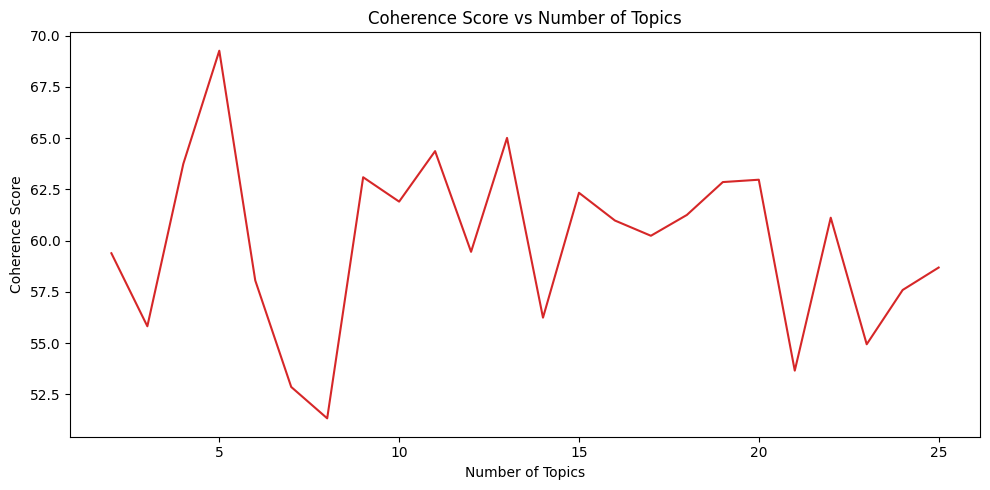

In [ ]:
# --- 7. VISUALIZE METRICS TO FIND THE BEST K ---
x = range(min_topics, max_topics + 1)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Coherence Score
color = 'tab:red'
ax1.set_xlabel('Number of Topics')
ax1.set_ylabel('Coherence Score' )
ax1.plot(x, coherence_scores,color=color )
ax1.tick_params(axis='y')
ax1.set_title('Coherence Score vs Number of Topics')

fig.tight_layout()
plt.show()

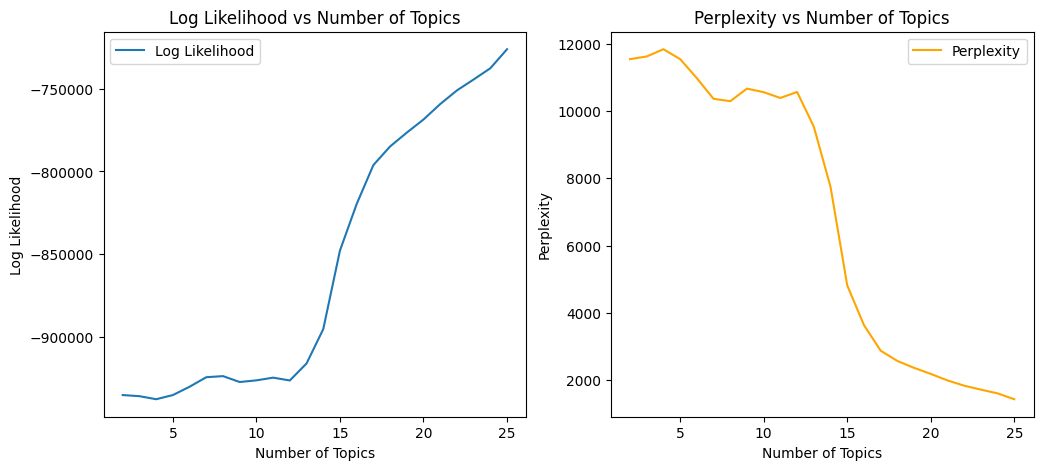

In [ ]:
# Create side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Log Likelihood ---
ax1.plot(x, log_likelihoods, color='tab:blue', label='Log Likelihood')
ax1.set_xlabel('Number of Topics')
ax1.set_ylabel('Log Likelihood')
ax1.set_title('Log Likelihood vs Number of Topics')
ax1.tick_params(axis='y')
ax1.legend()

# --- Plot 2: Perplexity ---
ax2.plot(x, perplexity_scores, color='orange', label='Perplexity')
ax2.set_xlabel('Number of Topics')
ax2.set_ylabel('Perplexity')
ax2.set_title('Perplexity vs Number of Topics')
ax2.tick_params(axis='y')
ax2.legend()

plt.show()


In [9]:
# Train the final model with the optimal number of topics (k=5)
optimal_k = 5

final_lda_model = LdaModel(
    corpus=train_corpus,
    id2word=train_dictionary,
    num_topics=optimal_k,
    random_state=100,
    passes=20,
    alpha='auto',
    chunksize=100,
    per_word_topics=True,
    update_every=1,
    eta='auto'
)

In [ ]:
# --- Evaluate on the Test Set ---
print("\n--- Evaluating Final Model on Test Data ---")

# Calculate perplexity on the test corpus
log_perplexity_test = final_lda_model.log_perplexity(test_corpus)
perplexity_test = np.exp2(log_perplexity_test)*10**6
final_coherence_model_lda = CoherenceModel(
    model=final_lda_model,
    texts=train_texts,
    dictionary=train_dictionary,
    coherence='c_v'

)
coherence_score = final_coherence_model_lda.get_coherence()
print(f"Coherence score : {100*coherence_score:.2f}")
print(f"Model Perplexity on Test Set: {perplexity_test:.2f}")


--- Evaluating Final Model on Test Data ---


In [14]:
import joblib

In [16]:
# Define the filenames for the model and dictionary
model_filename = 'lda_model.pkl'
dictionary_filename = 'train_dictionary.pkl'

# Save the trained model and dictionary
joblib.dump(final_lda_model, model_filename)
joblib.dump(train_dictionary, dictionary_filename)

print(f"Model saved to {model_filename}")
print(f"Dictionary saved to {dictionary_filename}")

# Download the saved files
files.download(model_filename)
files.download(dictionary_filename)

print("\nModel and dictionary files are ready for download.")

Model saved to lda_model.pkl
Dictionary saved to train_dictionary.pkl


NameError: name 'files' is not defined

In [ ]:
for idx, topic in final_lda_model.print_topics(num_topics=5, num_words=10):
    print(f"\nTopic #{idx + 1}:")
    # Parse and clean the topic words
    words = [word.split('*')[1].replace('"', '').strip() for word in topic.split('+')]
    print(f"  {', '.join(words)}")


Topic #1:
  board, director, year, member, report, financial, fiscal, auditor, statement, end

Topic #2:
  assembly, meeting, general, shareholder, end, meet, register, eligibility, mean, vote

Topic #3:
  percentage, profit, million, increase, sar, net, riyal, decrease, compare, saudi

Topic #4:
  capital, saudi, market, purchase, share, announce, financial, investor, investment, contract

Topic #5:
  share, date, dividend, distribution, trading, day, shareholder, announce, security, set


In [ ]:
!pip install wordcloud


--- Generating Word Clouds for Each Topic ---


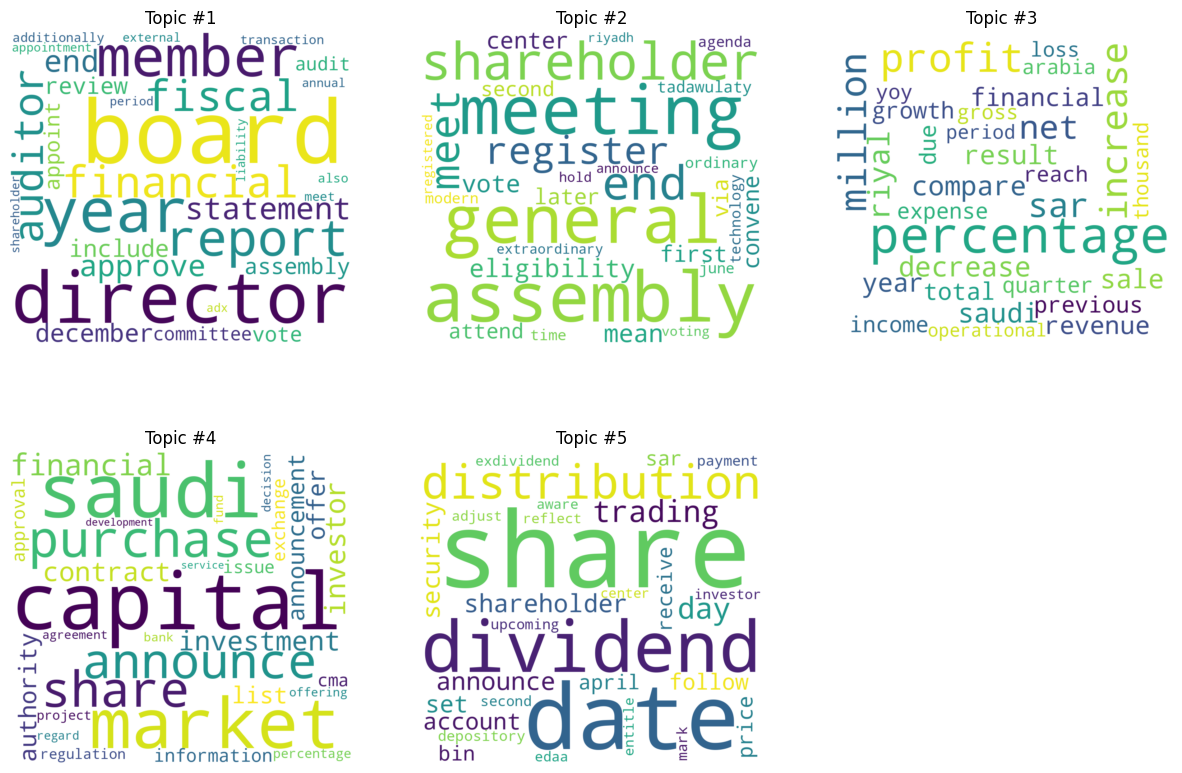


Word clouds generated and displayed.


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Assuming 'final_lda_model' and 'train_dictionary' are already defined

# Print top words for each topic and generate individual word clouds
print("\n--- Generating Word Clouds for Each Topic ---")

# Determine the number of topics
num_topics = final_lda_model.num_topics

# Calculate the number of rows and columns for subplots
# We'll aim for a roughly square layout or a layout that fits well
n_cols = 3  # You can adjust this number
n_rows = (num_topics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, topic in final_lda_model.show_topics(formatted=False, num_topics=num_topics, num_words=30):
    ax = axes[i] # Get the current subplot axis

    # Convert words and their weights into a dictionary format suitable for WordCloud
    topic_words = dict(topic)

    # Create a WordCloud object
    wordcloud = WordCloud(background_color="white", max_words=30,
                          width=1100, height=1000, colormap='viridis').generate_from_frequencies(topic_words)

    # Display the generated word cloud in the current subplot
    ax.imshow(wordcloud, interpolation="bilinear")
    ax.set_title(f"Topic #{i+1}", fontsize=12)
    ax.axis("off") # Hide axes

# Hide any unused subplots
for j in range(num_topics, len(axes)):
    fig.delaxes(axes[j])

# plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show() # Display the current figure

print("\nWord clouds generated and displayed.")

In [ ]:
print("\n" + "=" * 80)
print("DOCUMENT-TOPIC DISTRIBUTION ANALYSIS")
print("=" * 80)

# Create a corpus for all cleaned texts using the training dictionary
# Ensure `df['cleaned_text']` is tokenized correctly for the dictionary
all_texts = [train_dictionary.doc2bow(nltk.word_tokenize(doc)) for doc in df['cleaned_text']]

doc_topics_gensim = final_lda_model.get_document_topics(all_texts, minimum_probability=0.0)

# Convert to a format similar to what .transform() would produce (e.g., a matrix)
doc_topics = np.zeros((len(doc_topics_gensim), final_lda_model.num_topics))
for i, doc_tuple_list in enumerate(doc_topics_gensim):
    for topic_id, prob in doc_tuple_list:
        doc_topics[i, topic_id] = prob

print(f"\nTopic Distribution Statistics:")
print(f"  Average max probability: {doc_topics.max(axis=1).mean():.3f}")
print(f"  Docs with dominant topic (>0.5): {(doc_topics.max(axis=1) > 0.5).sum()} "
      f"({(doc_topics.max(axis=1) > 0.5).sum()/len(doc_topics)*100:.1f}%")

# Topic distribution across corpus
topic_counts = doc_topics.argmax(axis=1)
print(f"\n>>> Documents per topic:")
for topic_id in range(final_lda_model.num_topics):
    count = (topic_counts == topic_id).sum()
    print(f"  Topic {topic_id + 1}: {count} documents ({count/len(doc_topics)*100:.1f}%)")

# Show sample documents
print(f"\n>>> Sample Document Assignments (first 5):")
for i in range(min(5, len(doc_topics))):
    dominant_topic = doc_topics[i].argmax()
    confidence = doc_topics[i].max()
    print(f"  Doc {i}: Topic {dominant_topic + 1} (confidence: {confidence:.3f})")


DOCUMENT-TOPIC DISTRIBUTION ANALYSIS

Topic Distribution Statistics:
  Average max probability: 0.732
  Docs with dominant topic (>0.5): 2149 (83.5%

>>> Documents per topic:
  Topic 1: 341 documents (13.2%)
  Topic 2: 513 documents (19.9%)
  Topic 3: 511 documents (19.8%)
  Topic 4: 828 documents (32.2%)
  Topic 5: 382 documents (14.8%)

>>> Sample Document Assignments (first 5):
  Doc 0: Topic 5 (confidence: 0.578)
  Doc 1: Topic 4 (confidence: 0.833)
  Doc 2: Topic 4 (confidence: 0.693)
  Doc 3: Topic 4 (confidence: 0.697)
  Doc 4: Topic 4 (confidence: 0.452)


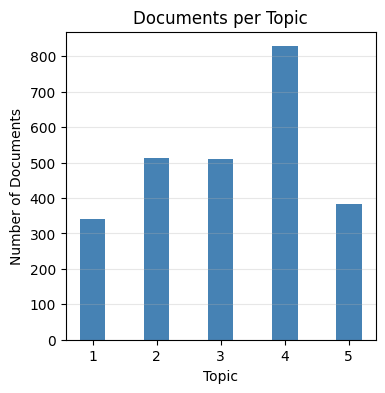

In [ ]:
# Plot 3: Topic distribution
topic_sizes = [(topic_counts == i).sum() for i in range(optimal_k)]
plt.figure(figsize=(4, 4))
plt.bar(range(1, optimal_k + 1), topic_sizes, color='steelblue', width=0.4)
plt.xlabel('Topic')
plt.ylabel('Number of Documents')
plt.title('Documents per Topic')
plt.xticks(range(1, optimal_k + 1))
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
# --- Visualize the Topics ---
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Set up the visualization tool
pyLDAvis.enable_notebook()

# The 'prepare' function generates the data for the visualization
# It's recommended to use the training corpus and dictionary for this
vis_data = gensimvis.prepare(final_lda_model, train_corpus, train_dictionary)

# Display the visualization
print("\n--- Interactive Topic Visualization ---")
vis_data

ModuleNotFoundError: No module named 'pyLDAvis'

In [ ]:
df.head()

,cleaned_text,sentiment
0,accord gran company plan move production russi...,neutral
1,technopolis plan develop stage area less squar...,neutral
2,international electronic industry company elco...,negative
3,new production plant company would increase ca...,positive
4,accord company update strategy year basware ta...,positive



Missing values:
 cleaned_text    0
sentiment       0
dtype: int64

Split sizes → Train: 2907, Val: 969, Test: 969

Validation Performance:
Accuracy: 0.718266253869969

Classification Report:
               precision    recall  f1-score   support

    negative       0.68      0.28      0.40       121
     neutral       0.73      0.94      0.82       575
    positive       0.69      0.45      0.54       273

    accuracy                           0.72       969
   macro avg       0.70      0.56      0.59       969
weighted avg       0.71      0.72      0.69       969


Test Performance:
Accuracy: 0.7420020639834881

Classification Report:
               precision    recall  f1-score   support

    negative       0.75      0.41      0.53       121
     neutral       0.74      0.94      0.83       576
    positive       0.74      0.47      0.58       272

    accuracy                           0.74       969
   macro avg       0.74      0.61      0.65       969
weighted avg       0.74    

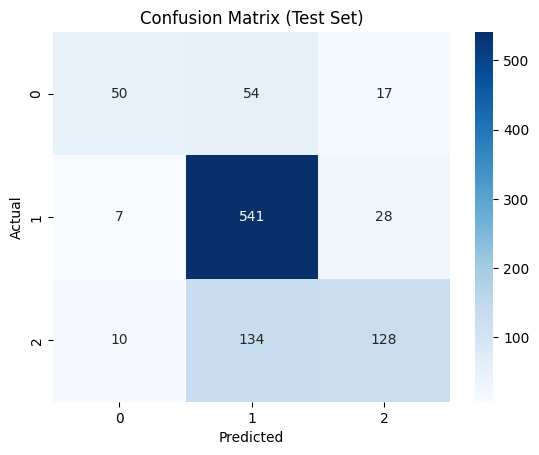


Sample Prediction: positive


In [ ]:
# @title
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df.dropna(subset=['cleaned_text'], inplace=True)
print("\nMissing values:\n", df.isnull().sum())

# First split train+val (80%) and test (20%)
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    df['cleaned_text'],
    df['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment']
)

# Then split train (70%) and validation (30%) from train_val
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts,
    train_val_labels,
    test_size=0.25,  # 0.25 * 0.8 = 0.2 → total 60/20/20
    random_state=42,
    stratify=train_val_labels
)

print(f"\nSplit sizes → Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")

# -----------------------------------------------
# 3. Convert text to TF-IDF features
# -----------------------------------------------
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)
X_test = vectorizer.transform(test_texts)

# 4. Train Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, train_labels)

# Get probability predictions for log loss
y_train_proba = lr.predict_proba(X_train_vec)
y_val_proba = lr.predict_proba(X_val)

# Calculate log loss
train_loss = log_loss(y_train, y_train_proba)
val_loss = log_loss(y_val, y_val_proba)

# 5. Evaluate on Validation Set
val_preds = model.predict(X_val)
print("\nValidation Performance:")
print("Accuracy:", accuracy_score(val_labels, val_preds))
print("\nClassification Report:\n", classification_report(val_labels, vpal_reds))

# 6. Evaluate on Test Set
test_preds = model.predict(X_test)

print("\nTest Performance:")
print("Accuracy:", accuracy_score(test_labels, test_preds))
print("\nClassification Report:\n", classification_report(test_labels, test_preds))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 7. Example: Predict on new text
sample_text = ["Company reports significant profit growth this quarter."]
sample_vec = vectorizer.transform(sample_text)
sample_pred = model.predict(sample_vec)
print("\nSample Prediction:", sample_pred[0])


Dataset shape: (4845, 2)

Class distribution:
sentiment
neutral     2878
positive    1363
negative     604
Name: count, dtype: int64

Data split sizes:
Training set: 2907 samples
Validation set: 969 samples
Test set: 969 samples

Feature matrix shape: (2907, 5000)

Training Logistic Regression models with varying regularization...
C= 0.001 | Train Loss: 1.0943 | Val Loss: 1.0949 | Val Acc: 0.6533
C= 0.010 | Train Loss: 1.0597 | Val Loss: 1.0654 | Val Acc: 0.6574
C= 0.100 | Train Loss: 0.8824 | Val Loss: 0.9288 | Val Acc: 0.7162
C= 0.500 | Train Loss: 0.6203 | Val Loss: 0.7642 | Val Acc: 0.7296
C= 1.000 | Train Loss: 0.4934 | Val Loss: 0.7036 | Val Acc: 0.7420
C= 2.000 | Train Loss: 0.3737 | Val Loss: 0.6625 | Val Acc: 0.7358
C= 5.000 | Train Loss: 0.2415 | Val Loss: 0.6469 | Val Acc: 0.7317
C=10.000 | Train Loss: 0.1644 | Val Loss: 0.6653 | Val Acc: 0.7276

Best C value based on validation loss: 5.0


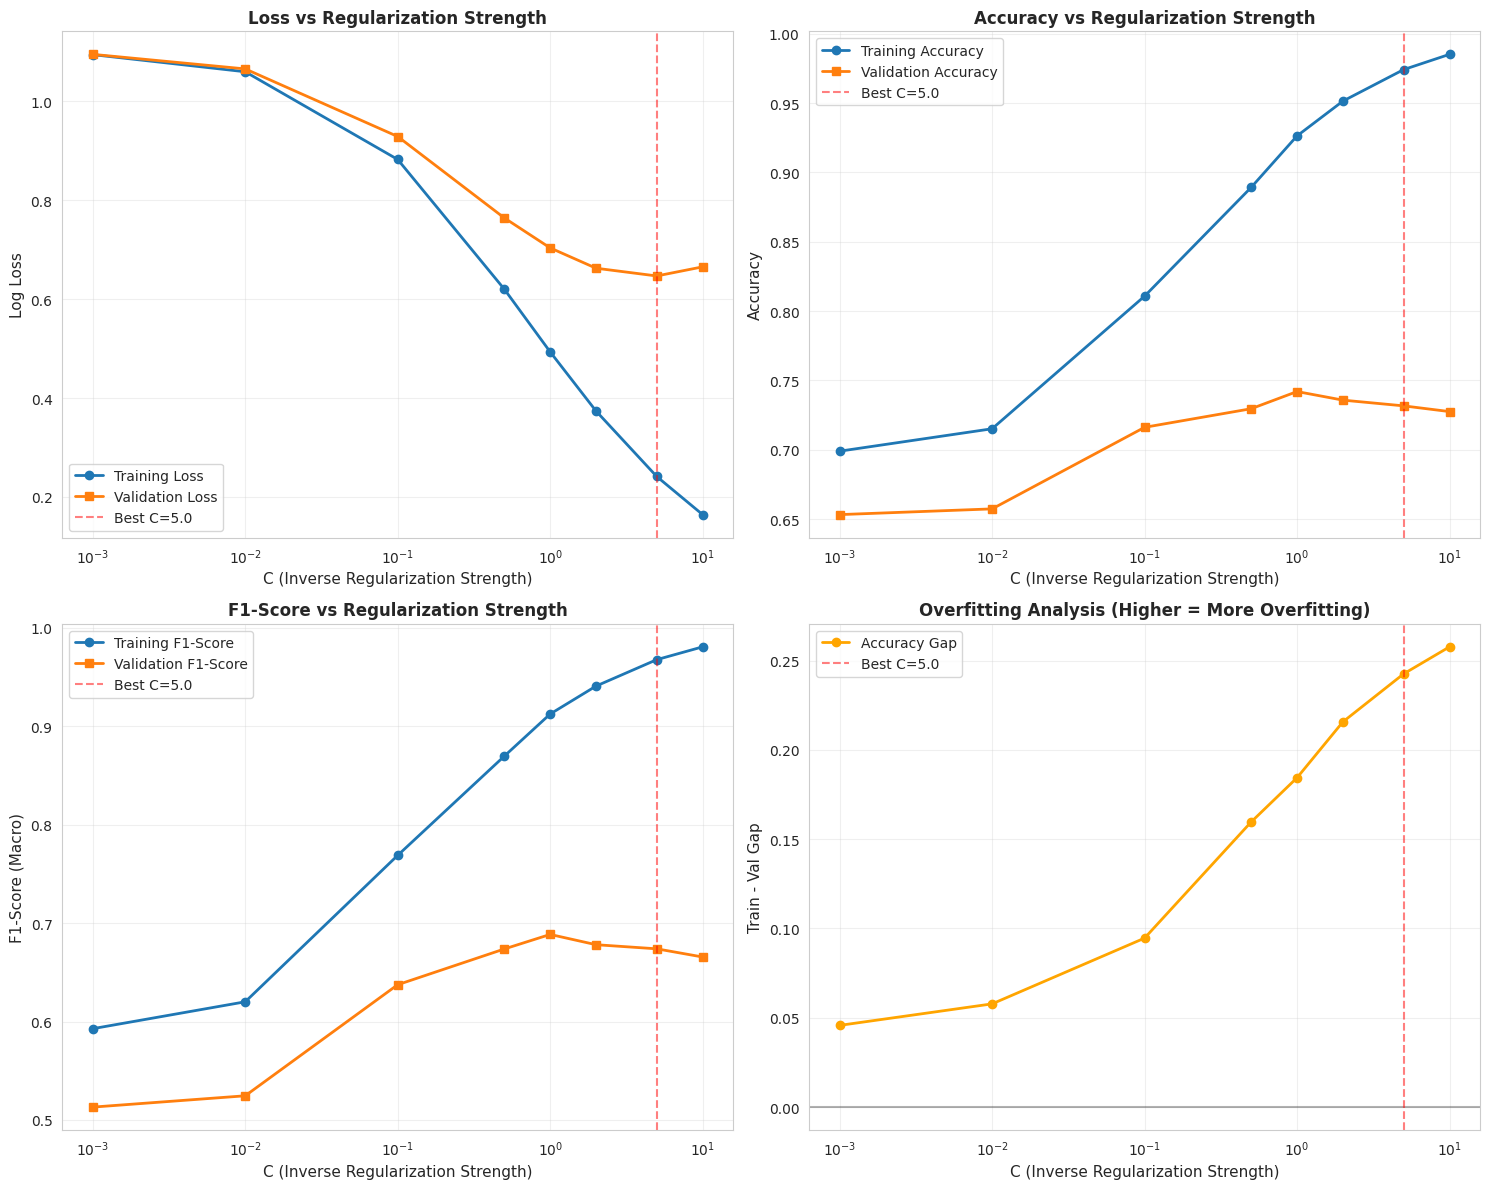


Training final model with C=5.0...

Training Set Evaluation
Log Loss: 0.2415
Accuracy: 0.9742

Macro Average:
  Precision: 0.9554
  Recall: 0.9814
  F1-Score: 0.9676

Weighted Average:
  Precision: 0.9755
  Recall: 0.9742
  F1-Score: 0.9744

Classification Report:
              precision    recall  f1-score   support

    negative       0.91      1.00      0.95       362
     neutral       1.00      0.97      0.98      1727
    positive       0.96      0.98      0.97       818

    accuracy                           0.97      2907
   macro avg       0.96      0.98      0.97      2907
weighted avg       0.98      0.97      0.97      2907


Validation Set Evaluation
Log Loss: 0.6469
Accuracy: 0.7317

Macro Average:
  Precision: 0.6730
  Recall: 0.6747
  F1-Score: 0.6738

Weighted Average:
  Precision: 0.7317
  Recall: 0.7317
  F1-Score: 0.7317

Classification Report:
              precision    recall  f1-score   support

    negative       0.59      0.60      0.59       121
     neutral

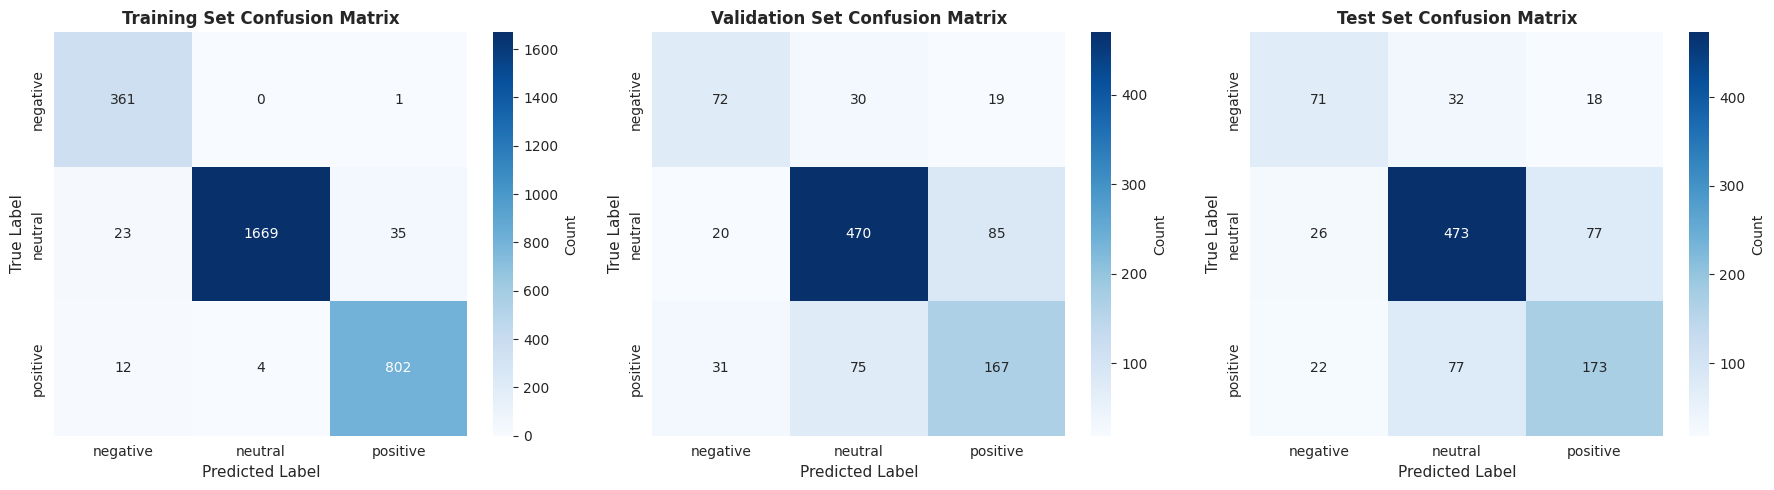


Summary of Model Performance
       Set     Loss  Accuracy  Precision   Recall  F1-Score
  Training 0.241455  0.974200   0.955422 0.981364  0.967623
Validation 0.646859  0.731682   0.672998 0.674718  0.673842
      Test 0.625815  0.739938   0.684959 0.681329  0.683111


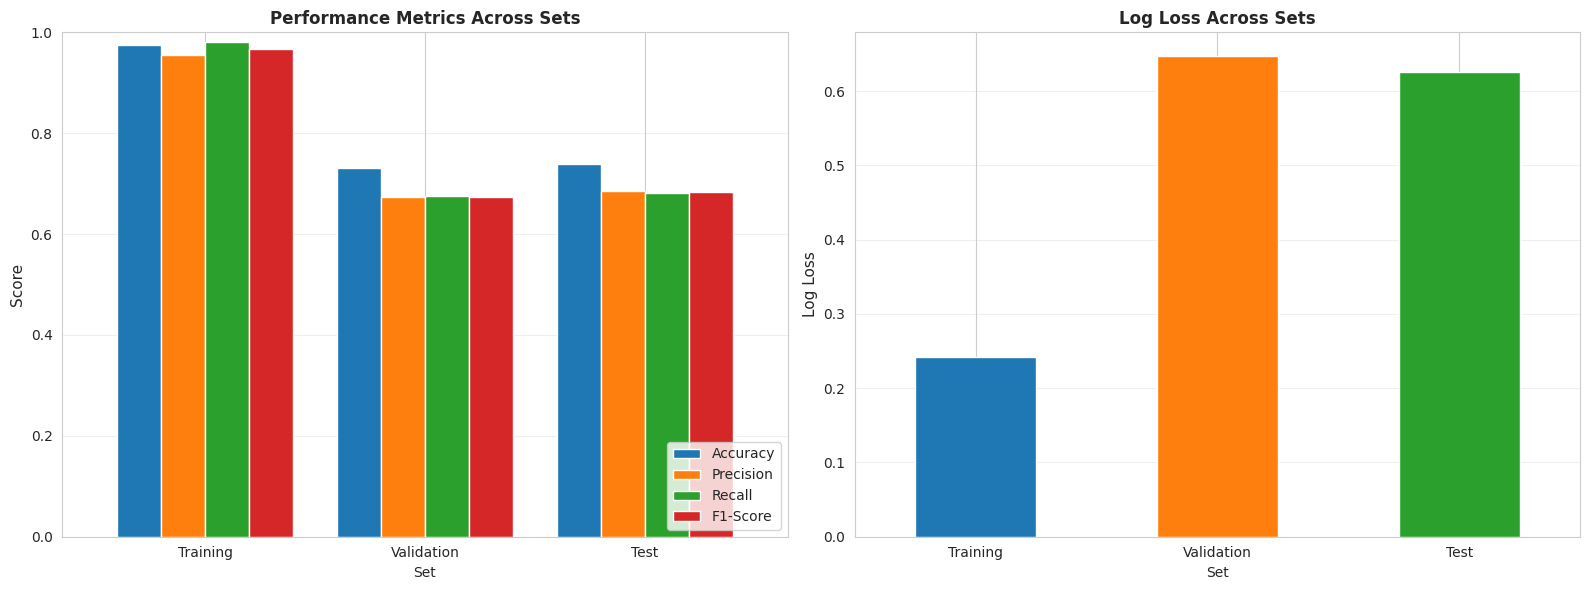


Model and vectorizer saved successfully!


In [ ]:
# @title
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             log_loss)
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load the cleaned data
df = pd.read_csv('cleaned_text_file.csv')
df.dropna(subset=['cleaned_text'], inplace=True)
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['sentiment'].value_counts())

# Prepare features and labels
X = df['cleaned_text']
y = df['sentiment']

# First split: separate test set (80% train+val, 20% test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: separate validation set (75% train, 25% val of the temp set)
# This gives us 60% train, 20% val, 20% test overall
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("\nData split sizes:")
print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

# Vectorize the text using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

print(f"\nFeature matrix shape: {X_train_vec.shape}")

# Train Logistic Regression with different C values to track learning
print("\nTraining Logistic Regression models with varying regularization...")

C_values = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f1_scores = []
val_f1_scores = []

for C in C_values:
    # Train model
    lr = LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
        solver='lbfgs',
        C=C
    )
    lr.fit(X_train_vec, y_train)

    # Get probability predictions for log loss
    y_train_proba = lr.predict_proba(X_train_vec)
    y_val_proba = lr.predict_proba(X_val_vec)

    # Calculate log loss
    train_loss = log_loss(y_train, y_train_proba)
    val_loss = log_loss(y_val, y_val_proba)

    # Get predictions
    y_train_pred = lr.predict(X_train_vec)
    y_val_pred = lr.predict(X_val_vec)

    # Calculate metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    val_f1 = f1_score(y_val, y_val_pred, average='macro')

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    train_f1_scores.append(train_f1)
    val_f1_scores.append(val_f1)

    print(f"C={C:6.3f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

# Find best C value based on validation loss
best_idx = np.argmin(val_losses)
best_C = C_values[best_idx]
print(f"\nBest C value based on validation loss: {best_C}")

# Plot 1: Loss Curves
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Loss vs Regularization
axes[0, 0].plot(C_values, train_losses, marker='o', label='Training Loss', linewidth=2)
axes[0, 0].plot(C_values, val_losses, marker='s', label='Validation Loss', linewidth=2)
axes[0, 0].axvline(x=best_C, color='r', linestyle='--', alpha=0.5, label=f'Best C={best_C}')
axes[0, 0].set_xlabel('C (Inverse Regularization Strength)', fontsize=11)
axes[0, 0].set_ylabel('Log Loss', fontsize=11)
axes[0, 0].set_title('Loss vs Regularization Strength', fontsize=12, fontweight='bold')
axes[0, 0].set_xscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy vs Regularization
axes[0, 1].plot(C_values, train_accuracies, marker='o', label='Training Accuracy', linewidth=2)
axes[0, 1].plot(C_values, val_accuracies, marker='s', label='Validation Accuracy', linewidth=2)
axes[0, 1].axvline(x=best_C, color='r', linestyle='--', alpha=0.5, label=f'Best C={best_C}')
axes[0, 1].set_xlabel('C (Inverse Regularization Strength)', fontsize=11)
axes[0, 1].set_ylabel('Accuracy', fontsize=11)
axes[0, 1].set_title('Accuracy vs Regularization Strength', fontsize=12, fontweight='bold')
axes[0, 1].set_xscale('log')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1-Score vs Regularization
axes[1, 0].plot(C_values, train_f1_scores, marker='o', label='Training F1-Score', linewidth=2)
axes[1, 0].plot(C_values, val_f1_scores, marker='s', label='Validation F1-Score', linewidth=2)
axes[1, 0].axvline(x=best_C, color='r', linestyle='--', alpha=0.5, label=f'Best C={best_C}')
axes[1, 0].set_xlabel('C (Inverse Regularization Strength)', fontsize=11)
axes[1, 0].set_ylabel('F1-Score (Macro)', fontsize=11)
axes[1, 0].set_title('F1-Score vs Regularization Strength', fontsize=12, fontweight='bold')
axes[1, 0].set_xscale('log')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Overfitting Analysis
gap_acc = np.array(train_accuracies) - np.array(val_accuracies)
gap_loss = np.array(val_losses) - np.array(train_losses)
axes[1, 1].plot(C_values, gap_acc, marker='o', label='Accuracy Gap', linewidth=2, color='orange')
axes[1, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1, 1].axvline(x=best_C, color='r', linestyle='--', alpha=0.5, label=f'Best C={best_C}')
axes[1, 1].set_xlabel('C (Inverse Regularization Strength)', fontsize=11)
axes[1, 1].set_ylabel('Train - Val Gap', fontsize=11)
axes[1, 1].set_title('Overfitting Analysis (Higher = More Overfitting)', fontsize=12, fontweight='bold')
axes[1, 1].set_xscale('log')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Train final model with best C
print(f"\nTraining final model with C={best_C}...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    solver='lbfgs',
    C=best_C
)
lr_model.fit(X_train_vec, y_train)

# Predictions on all sets
y_train_pred = lr_model.predict(X_train_vec)
y_val_pred = lr_model.predict(X_val_vec)
y_test_pred = lr_model.predict(X_test_vec)

y_train_proba = lr_model.predict_proba(X_train_vec)
y_val_proba = lr_model.predict_proba(X_val_vec)
y_test_proba = lr_model.predict_proba(X_test_vec)

# Calculate losses
train_loss = log_loss(y_train, y_train_proba)
val_loss = log_loss(y_val, y_val_proba)
test_loss = log_loss(y_test, y_test_proba)

# Function to calculate all metrics
def evaluate_model(y_true, y_pred, y_proba, set_name):
    print(f"\n{'='*60}")
    print(f"{set_name} Set Evaluation")
    print('='*60)

    loss = log_loss(y_true, y_proba)
    acc = accuracy_score(y_true, y_pred)

    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

    prec_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"Log Loss: {loss:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"\nMacro Average:")
    print(f"  Precision: {prec_macro:.4f}")
    print(f"  Recall: {rec_macro:.4f}")
    print(f"  F1-Score: {f1_macro:.4f}")
    print(f"\nWeighted Average:")
    print(f"  Precision: {prec_weighted:.4f}")
    print(f"  Recall: {rec_weighted:.4f}")
    print(f"  F1-Score: {f1_weighted:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return loss, acc, prec_macro, rec_macro, f1_macro

# Evaluate on all sets
train_metrics = evaluate_model(y_train, y_train_pred, y_train_proba, "Training")
val_metrics = evaluate_model(y_val, y_val_pred, y_val_proba, "Validation")
test_metrics = evaluate_model(y_test, y_test_pred, y_test_proba, "Test")

# Plot 2: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (y_true, y_pred, title) in enumerate([
    (y_train, y_train_pred, 'Training'),
    (y_val, y_val_pred, 'Validation'),
    (y_test, y_test_pred, 'Test')
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=lr_model.classes_, yticklabels=lr_model.classes_,
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{title} Set Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=11)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Comprehensive Metrics Comparison
metrics_df = pd.DataFrame({
    'Set': ['Training', 'Validation', 'Test'],
    'Loss': [train_metrics[0], val_metrics[0], test_metrics[0]],
    'Accuracy': [train_metrics[1], val_metrics[1], test_metrics[1]],
    'Precision': [train_metrics[2], val_metrics[2], test_metrics[2]],
    'Recall': [train_metrics[3], val_metrics[3], test_metrics[3]],
    'F1-Score': [train_metrics[4], val_metrics[4], test_metrics[4]]
})

print("\n" + "="*60)
print("Summary of Model Performance")
print("="*60)
print(metrics_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Metrics bar chart
metrics_plot = metrics_df.set_index('Set')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
metrics_plot.plot(kind='bar', ax=axes[0], rot=0, width=0.8)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Performance Metrics Across Sets', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Loss bar chart
metrics_df.set_index('Set')['Loss'].plot(kind='bar', ax=axes[1], rot=0,
                                          color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('Log Loss', fontsize=11)
axes[1].set_title('Log Loss Across Sets', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Save the model and vectorizer
import joblib
joblib.dump(lr_model, 'logistic_regression_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("\nModel and vectorizer saved successfully!")

# Plot 4: Per-Class Performance
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# for idx, (y_true, y_pred, title) in enumerate([
#     (y_train, y_train_pred, 'Training'),
#     (y_val, y_val_pred, 'Validation'),
#     (y_test, y_test_pred, 'Test')
# ]):
#     report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
#     classes = [c for c in report.keys() if c not in ['accuracy', 'macro avg', 'weighted avg']]

#     metrics_per_class = {
#         'Precision': [report[c]['precision'] for c in classes],
#         'Recall': [report[c]['recall'] for c in classes],
#         'F1-Score': [report[c]['f1-score'] for c in classes]
#     }

#     x = np.arange(len(classes))
#     width = 0.25

#     axes[idx].bar(x - width, metrics_per_class['Precision'], width, label='Precision', alpha=0.8)
#     axes[idx].bar(x, metrics_per_class['Recall'], width, label='Recall', alpha=0.8)
#     axes[idx].bar(x + width, metrics_per_class['F1-Score'], width, label='F1-Score', alpha=0.8)

#     axes[idx].set_xlabel('Sentiment Class', fontsize=11)
#     axes[idx].set_ylabel('Score', fontsize=11)
#     axes[idx].set_title(f'{title} Set - Per Class Metrics', fontsize=12, fontweight='bold')
#     axes[idx].set_xticks(x)
#     axes[idx].set_xticklabels(classes, rotation=0)
#     axes[idx].legend()
#     axes[idx].set_ylim([0, 1])
#     axes[idx].grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.savefig('per_class_metrics.png', dpi=300, bbox_inches='tight')
# plt.show()


# # Example predictions
# print("\n" + "="*60)
# print("Example Predictions on Test Set")
# print("="*60)
# sample_indices = np.random.choice(len(X_test), 5, replace=False)
# for idx in sample_indices:
#     text = X_test.iloc[idx]
#     true_label = y_test.iloc[idx]
#     pred_label = y_test_pred[idx]
#     probas = y_test_proba[idx]

#     print(f"\nText: {text[:100]}...")
#     print(f"True: {true_label} | Predicted: {pred_label}")
#     print(f"Confidence scores: {dict(zip(lr_model.classes_, probas))}")

Loading data...
Dataset shape: (4845, 2)

Class distribution:
sentiment
neutral     2878
positive    1363
negative     604
Name: count, dtype: int64

Training set: 2907 samples
Validation set: 969 samples
Test set: 969 samples

Vectorizing text...
Feature matrix shape: (2907, 5000)

TRAINING AND EVALUATING MODELS

Training Logistic Regression...
Training Time: 16.15 seconds

Test Set Performance:
  Accuracy:  0.7307
  Precision: 0.6699
  Recall:    0.6821
  F1-Score:  0.6752
  Log Loss:  0.6950

Classification Report (Test Set):
              precision    recall  f1-score   support

    negative       0.57      0.64      0.60       121
     neutral       0.82      0.81      0.81       576
    positive       0.63      0.60      0.61       272

    accuracy                           0.73       969
   macro avg       0.67      0.68      0.68       969
weighted avg       0.73      0.73      0.73       969


Training Linear SVM...
Training Time: 0.02 seconds

Test Set Performance:
  Accurac

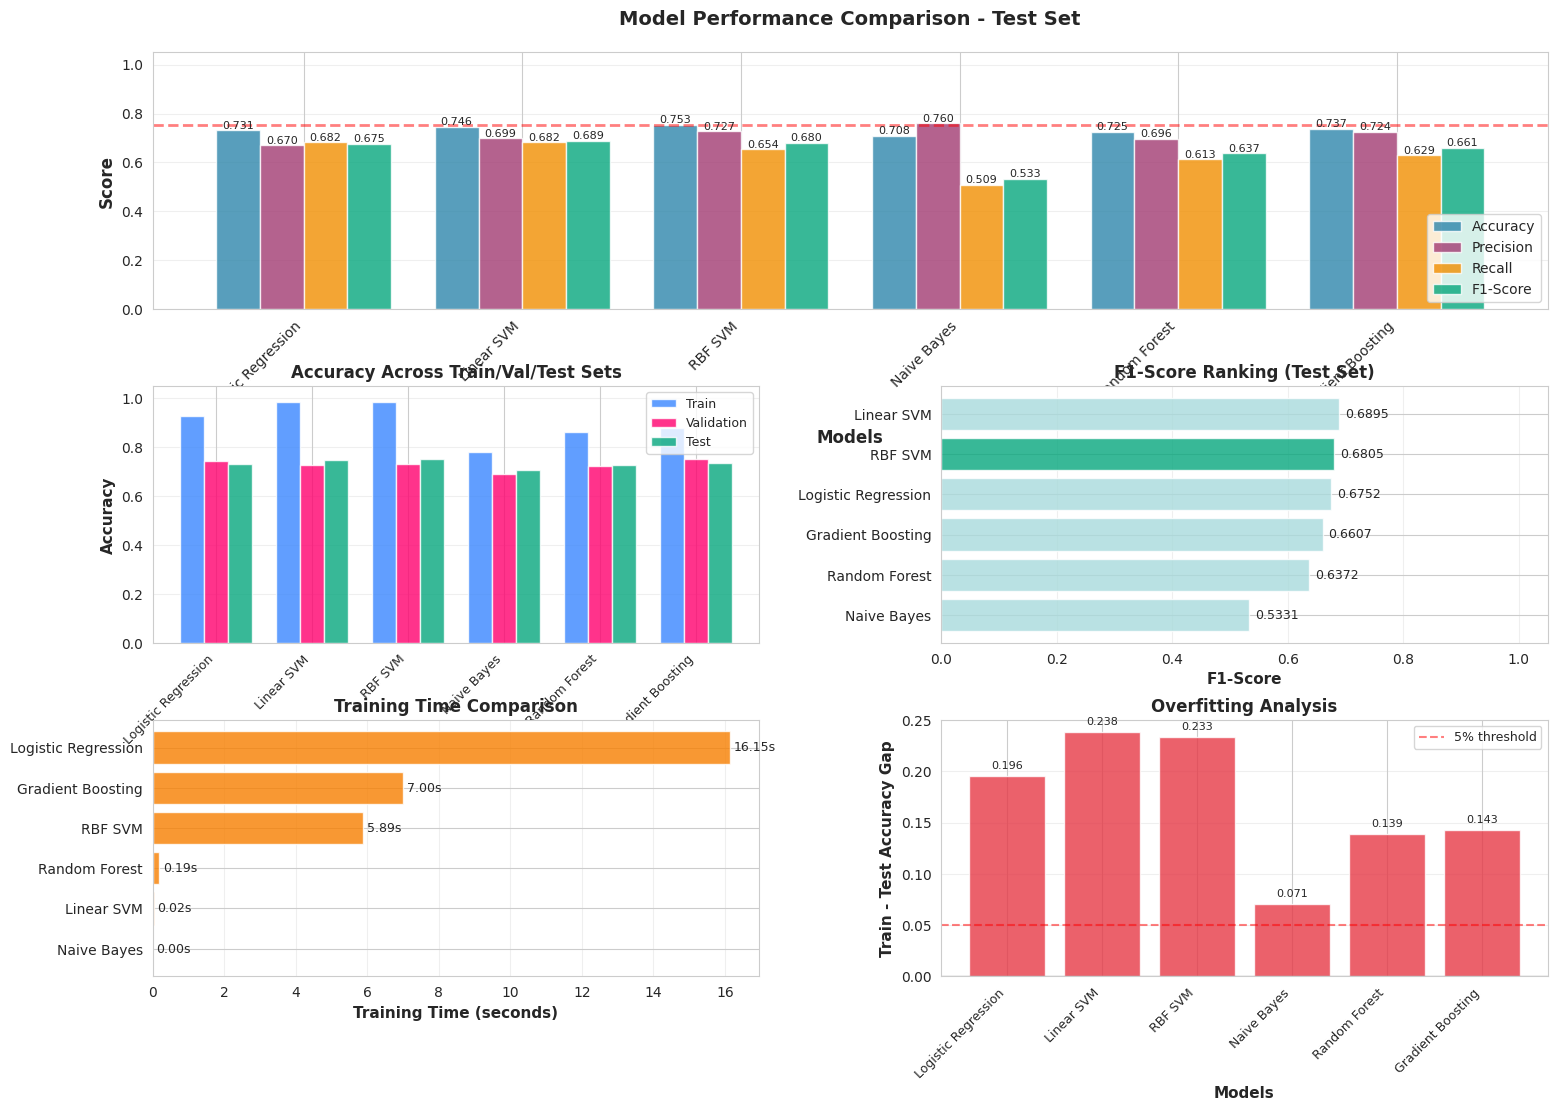

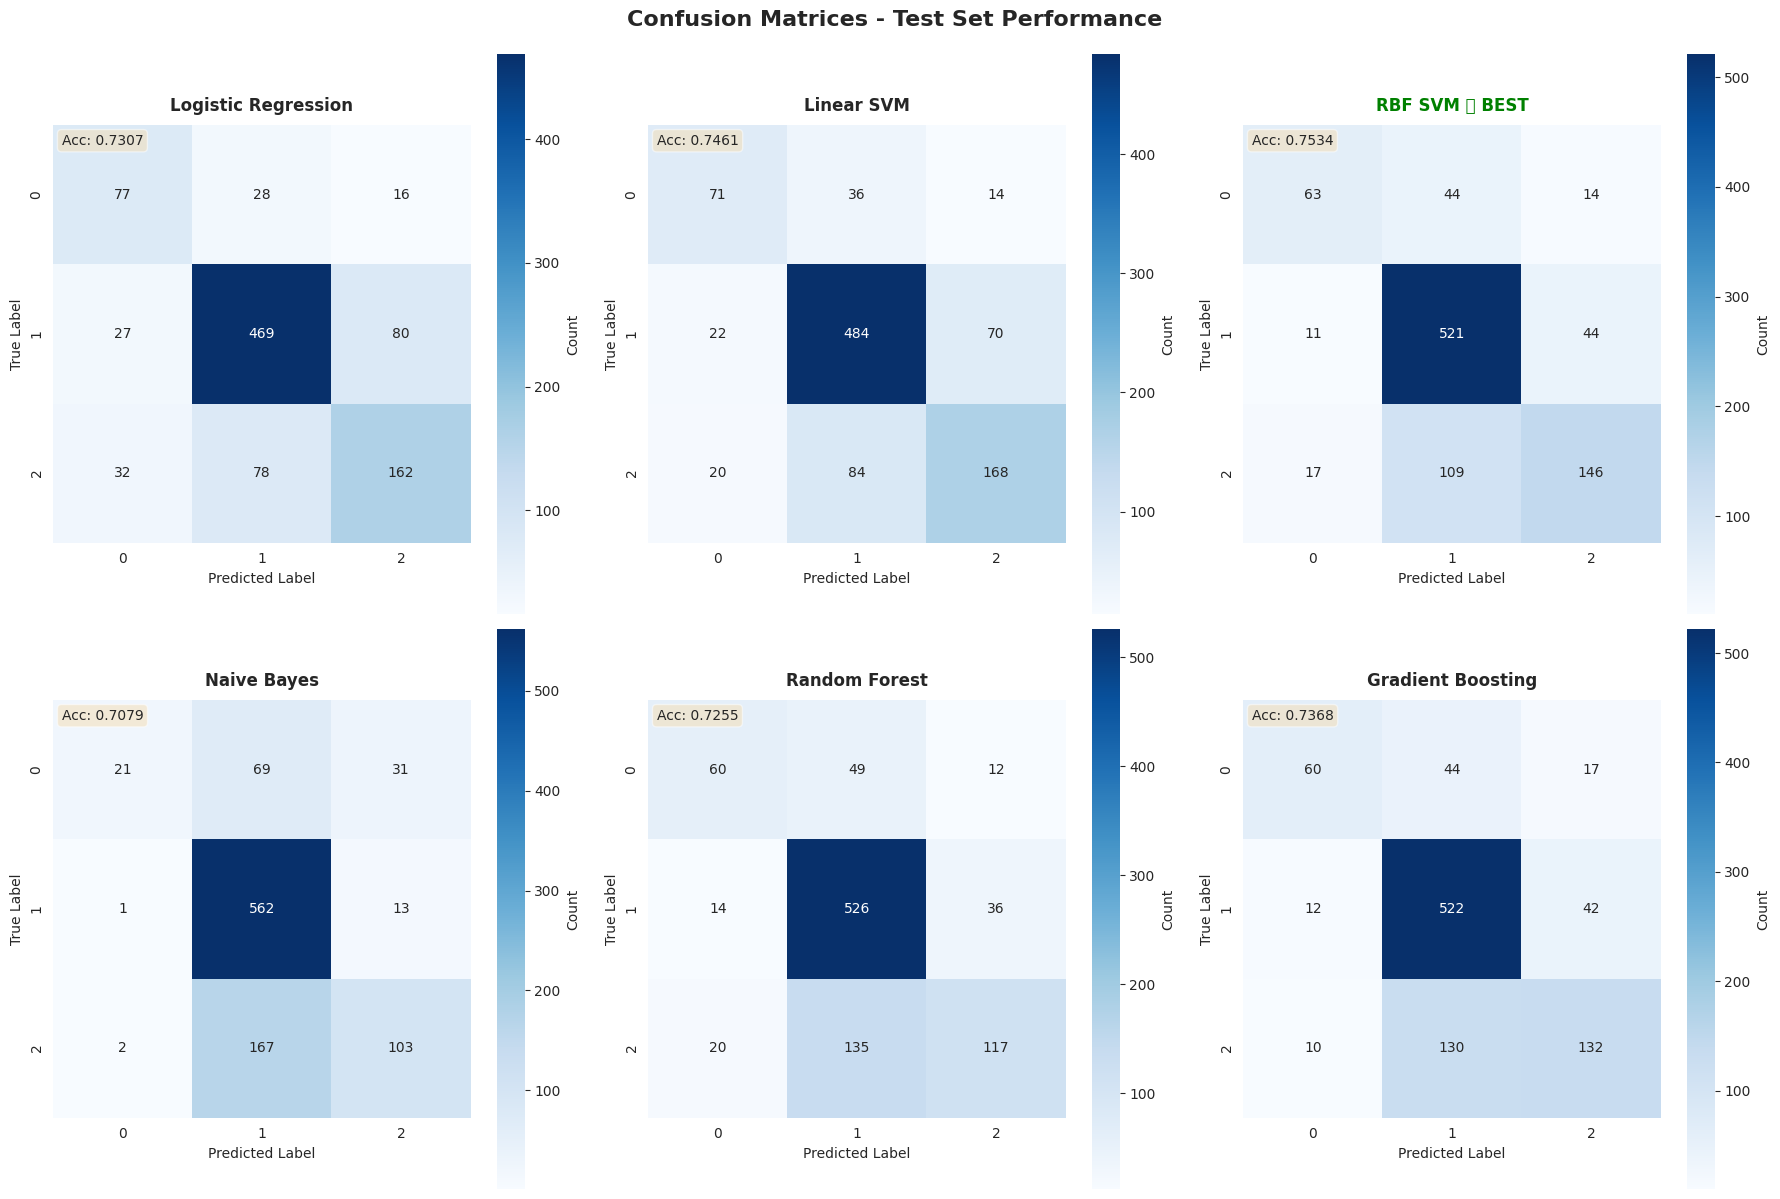


Saving best model (RBF SVM)...

All models trained and evaluated successfully!
Best model (RBF SVM) saved as 'best_model.pkl'
Vectorizer saved as 'tfidf_vectorizer.pkl'
Results saved as 'model_comparison_results.pkl'


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             log_loss)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from time import time
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

# Load the cleaned data
print("Loading data...")
df = pd.read_csv('cleaned_text_file.csv')
df.dropna(subset=['cleaned_text'], inplace=True)
print(f"Dataset shape: {df.shape}")
print("\nClass distribution:")
print(df['sentiment'].value_counts())

# Prepare features and labels
X = df['cleaned_text']
y = df['sentiment']

# Split data: 60% train, 20% validation, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

# Vectorize the text using TF-IDF
print("\nVectorizing text...")
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

print(f"Feature matrix shape: {X_train_vec.shape}")

# Define models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
        solver='lbfgs',
        C=1.0
    ),
    'Linear SVM': LinearSVC(
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
        C=1.0
    ),
    'RBF SVM': SVC(
        kernel='rbf',
        random_state=42,
        class_weight='balanced',
        probability=True,
        C=1.0,
        gamma='scale'
    ),
    'Naive Bayes': MultinomialNB(alpha=1.0),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced',
        max_depth=20,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=5,
        learning_rate=0.1
    )
}

# Store results
results = []
trained_models = {}
confusion_matrices = {}

print("\n" + "="*80)
print("TRAINING AND EVALUATING MODELS")
print("="*80)

# Train and evaluate each model
for model_name, model in models.items():
    print(f"\n{'='*80}")
    print(f"Training {model_name}...")
    print('='*80)

    start_time = time()

    # Train model
    model.fit(X_train_vec, y_train)
    training_time = time() - start_time

    # Make predictions
    y_train_pred = model.predict(X_train_vec)
    y_val_pred = model.predict(X_val_vec)
    y_test_pred = model.predict(X_test_vec)

    # Get probabilities (if available)
    if hasattr(model, 'predict_proba'):
        y_train_proba = model.predict_proba(X_train_vec)
        y_val_proba = model.predict_proba(X_val_vec)
        y_test_proba = model.predict_proba(X_test_vec)

        train_loss = log_loss(y_train, y_train_proba)
        val_loss = log_loss(y_val, y_val_proba)
        test_loss = log_loss(y_test, y_test_proba)
    else:
        train_loss = val_loss = test_loss = np.nan

    # Calculate metrics for each set
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_prec = precision_score(y_train, y_train_pred, average='macro', zero_division=0)
    val_prec = precision_score(y_val, y_val_pred, average='macro', zero_division=0)
    test_prec = precision_score(y_test, y_test_pred, average='macro', zero_division=0)

    train_rec = recall_score(y_train, y_train_pred, average='macro', zero_division=0)
    val_rec = recall_score(y_val, y_val_pred, average='macro', zero_division=0)
    test_rec = recall_score(y_test, y_test_pred, average='macro', zero_division=0)

    train_f1 = f1_score(y_train, y_train_pred, average='macro', zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, average='macro', zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

    # Store results
    results.append({
        'Model': model_name,
        'Train_Acc': train_acc,
        'Val_Acc': val_acc,
        'Test_Acc': test_acc,
        'Train_Prec': train_prec,
        'Val_Prec': val_prec,
        'Test_Prec': test_prec,
        'Train_Rec': train_rec,
        'Val_Rec': val_rec,
        'Test_Rec': test_rec,
        'Train_F1': train_f1,
        'Val_F1': val_f1,
        'Test_F1': test_f1,
        'Train_Loss': train_loss,
        'Val_Loss': val_loss,
        'Test_Loss': test_loss,
        'Training_Time': training_time
    })

    # Store confusion matrix
    confusion_matrices[model_name] = confusion_matrix(y_test, y_test_pred)

    # Store trained model
    trained_models[model_name] = model

    # Print results
    print(f"Training Time: {training_time:.2f} seconds")
    print(f"\nTest Set Performance:")
    print(f"  Accuracy:  {test_acc:.4f}")
    print(f"  Precision: {test_prec:.4f}")
    print(f"  Recall:    {test_rec:.4f}")
    print(f"  F1-Score:  {test_f1:.4f}")
    if not np.isnan(test_loss):
        print(f"  Log Loss:  {test_loss:.4f}")

    print(f"\nClassification Report (Test Set):")
    print(classification_report(y_test, y_test_pred, zero_division=0))

# Create results dataframe
results_df = pd.DataFrame(results)

# Print summary table
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY - TEST SET PERFORMANCE")
print("="*80)
summary_df = results_df[['Model', 'Test_Acc', 'Test_Prec', 'Test_Rec', 'Test_F1', 'Training_Time']]
summary_df.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Time (s)']
print(summary_df.to_string(index=False))

# Find best model
best_model_idx = results_df['Test_Acc'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_accuracy = results_df.loc[best_model_idx, 'Test_Acc']

print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name} with Test Accuracy: {best_accuracy:.4f}")
print('='*80)

# ============================================================================
# VISUALIZATION 1: Main Comparison Plot
# ============================================================================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Plot 1: Test Set Metrics Comparison (Main Plot)
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(results_df))
width = 0.2

metrics = ['Test_Acc', 'Test_Prec', 'Test_Rec', 'Test_F1']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D']

for i, (metric, name, color) in enumerate(zip(metrics, metric_names, colors)):
    offset = width * (i - 1.5)
    bars = ax1.bar(x + offset, results_df[metric], width, label=name, color=color, alpha=0.8)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

ax1.set_xlabel('Models', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance Comparison - Test Set', fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax1.legend(loc='lower right', fontsize=10)
ax1.set_ylim([0, 1.05])
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=best_accuracy, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Best Accuracy')

# Plot 2: Training vs Validation vs Test Accuracy
ax2 = fig.add_subplot(gs[1, 0])
x = np.arange(len(results_df))
width = 0.25

ax2.bar(x - width, results_df['Train_Acc'], width, label='Train', color='#3A86FF', alpha=0.8)
ax2.bar(x, results_df['Val_Acc'], width, label='Validation', color='#FF006E', alpha=0.8)
ax2.bar(x + width, results_df['Test_Acc'], width, label='Test', color='#06A77D', alpha=0.8)

ax2.set_xlabel('Models', fontsize=11, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax2.set_title('Accuracy Across Train/Val/Test Sets', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=9)
ax2.legend(fontsize=9)
ax2.set_ylim([0, 1.05])
ax2.grid(axis='y', alpha=0.3)

# Plot 3: F1-Score Comparison
ax3 = fig.add_subplot(gs[1, 1])
sorted_idx = results_df['Test_F1'].sort_values(ascending=True).index
sorted_models = results_df.loc[sorted_idx, 'Model']
sorted_f1 = results_df.loc[sorted_idx, 'Test_F1']

colors_f1 = ['#06A77D' if model == best_model_name else '#A8DADC' for model in sorted_models]
bars = ax3.barh(sorted_models, sorted_f1, color=colors_f1, alpha=0.8)

for i, (bar, val) in enumerate(zip(bars, sorted_f1)):
    ax3.text(val + 0.01, i, f'{val:.4f}', va='center', fontsize=9)

ax3.set_xlabel('F1-Score', fontsize=11, fontweight='bold')
ax3.set_title('F1-Score Ranking (Test Set)', fontsize=12, fontweight='bold')
ax3.set_xlim([0, 1.05])
ax3.grid(axis='x', alpha=0.3)

# Plot 4: Training Time Comparison
ax4 = fig.add_subplot(gs[2, 0])
sorted_idx_time = results_df['Training_Time'].sort_values(ascending=True).index
sorted_models_time = results_df.loc[sorted_idx_time, 'Model']
sorted_time = results_df.loc[sorted_idx_time, 'Training_Time']

bars_time = ax4.barh(sorted_models_time, sorted_time, color='#F77F00', alpha=0.8)

for i, (bar, val) in enumerate(zip(bars_time, sorted_time)):
    ax4.text(val + 0.1, i, f'{val:.2f}s', va='center', fontsize=9)

ax4.set_xlabel('Training Time (seconds)', fontsize=11, fontweight='bold')
ax4.set_title('Training Time Comparison', fontsize=12, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

# Plot 5: Overfitting Analysis
ax5 = fig.add_subplot(gs[2, 1])
overfitting_gap = results_df['Train_Acc'] - results_df['Test_Acc']
colors_overfit = ['#E63946' if gap > 0.05 else '#06A77D' for gap in overfitting_gap]

bars_overfit = ax5.bar(x, overfitting_gap, color=colors_overfit, alpha=0.8)

for i, (bar, val) in enumerate(zip(bars_overfit, overfitting_gap)):
    ax5.text(i, val + 0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax5.set_xlabel('Models', fontsize=11, fontweight='bold')
ax5.set_ylabel('Train - Test Accuracy Gap', fontsize=11, fontweight='bold')
ax5.set_title('Overfitting Analysis', fontsize=12, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=9)
ax5.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax5.axhline(y=0.05, color='red', linestyle='--', alpha=0.5, label='5% threshold')
ax5.legend(fontsize=9)
ax5.grid(axis='y', alpha=0.3)

plt.savefig('model_comparison_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# VISUALIZATION 2: Confusion Matrices for All Models
# ============================================================================
n_models = len(models)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (model_name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar_kws={'label': 'Count'}, square=True)

    # Highlight best model
    if model_name == best_model_name:
        axes[idx].set_title(f'{model_name} ⭐ BEST', fontsize=12, fontweight='bold',
                           color='green', pad=10)
    else:
        axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold', pad=10)

    axes[idx].set_ylabel('True Label', fontsize=10)
    axes[idx].set_xlabel('Predicted Label', fontsize=10)

    # Add accuracy to subplot
    model_acc = results_df[results_df['Model'] == model_name]['Test_Acc'].values[0]
    axes[idx].text(0.02, 0.98, f'Acc: {model_acc:.4f}',
                  transform=axes[idx].transAxes, fontsize=10,
                  verticalalignment='top', bbox=dict(boxstyle='round',
                  facecolor='wheat', alpha=0.5))

plt.suptitle('Confusion Matrices - Test Set Performance', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

# Save the best model and vectorizer
print(f"\nSaving best model ({best_model_name})...")
joblib.dump(trained_models[best_model_name], 'best_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(results_df, 'model_comparison_results.pkl')

print("\n" + "="*80)
print("All models trained and evaluated successfully!")
print(f"Best model ({best_model_name}) saved as 'best_model.pkl'")
print("Vectorizer saved as 'tfidf_vectorizer.pkl'")
print("Results saved as 'model_comparison_results.pkl'")
print("="*80)

In [ ]:
# This is the magic line that enables the interactive display in your notebook
pyLDAvis.enable_notebook()

# Prepare the visualization data using your final model, training corpus, and dictionary
vis_data = gensimvis.prepare(final_lda_model, train_corpus, train_dictionary)

vis_data

In [ ]:
!pip install pyLDAvis


In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=1319) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


  -> Coherence (C_v): 0.4200
  -> Perplexity: 299.9228
  -> log_likelihood: -8.2284



/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=1319) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


  -> Coherence (C_v): 0.4301
  -> Perplexity: 328.1666
  -> log_likelihood: -8.3583



/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=1319) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


  -> Coherence (C_v): 0.4721
  -> Perplexity: 387.0954
  -> log_likelihood: -8.5965



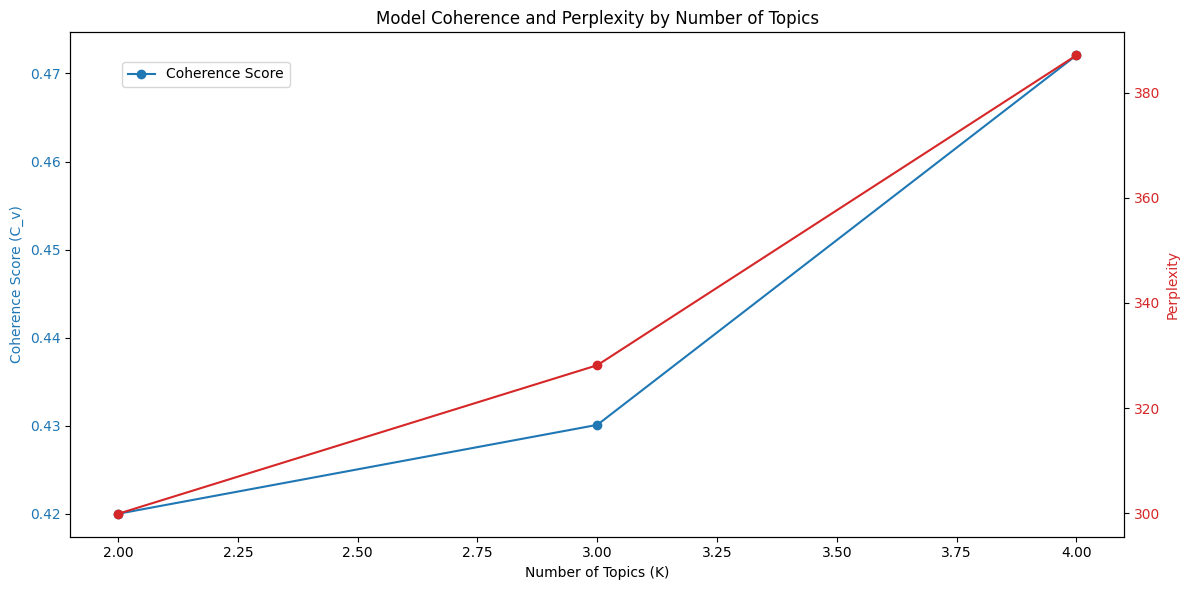

Optimal number of topics: 4


In [ ]:
import nltk
import pandas as pd
from gensim.corpora import Dictionary
from gensim.models import LdaMulticore, CoherenceModel
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# --- 1. LOAD DATA ---
df.dropna(subset=["cleaned_text"], inplace=True)

# --- 2. SPLIT DATA ---
train_docs, temp_docs = train_test_split(df["cleaned_text"], test_size=0.3, random_state=42)
val_docs, test_docs = train_test_split(temp_docs, test_size=0.5, random_state=42)

# --- 3. TOKENIZE ---
train_texts = [nltk.word_tokenize(doc.lower()) for doc in train_docs]
val_texts = [nltk.word_tokenize(doc.lower()) for doc in val_docs]
test_texts = [nltk.word_tokenize(doc.lower()) for doc in test_docs]

# --- 4. CREATE DICTIONARY & CORPUS ---
train_dictionary = Dictionary(train_texts)
train_dictionary.filter_extremes(no_below=3, no_above=0.8)

train_corpus = [train_dictionary.doc2bow(text) for text in train_texts]
val_corpus = [train_dictionary.doc2bow(text) for text in val_texts]

# --- 5. LDA HYPERPARAMETER TUNING ---
min_topics, max_topics = 2, 4
coherence_scores = []
perplexity_scores = []

for k in range(min_topics, max_topics + 1):
    lda_model = LdaMulticore(
        corpus=train_corpus,
        id2word=train_dictionary,
        num_topics=k,
        passes=20,
        random_state=42,
        chunksize=2000,
        eval_every=1,
        iterations=100,
        alpha='asymmetric',
        eta=0.01,
        per_word_topics=True
    )

    coherence = CoherenceModel(
        model=lda_model,
        texts=val_texts,
        dictionary=train_dictionary,
        coherence='c_v',
        processes=1
    ).get_coherence()

    log_perplexity = lda_model.log_perplexity(val_corpus, total_docs=len(val_docs))
    perplexity = np.exp2(-log_perplexity)
    print(f"  -> Coherence (C_v): {coherence:.4f}")
    print(f"  -> Perplexity: {perplexity:.4f}")
    print(f"  -> log_likelihood: {log_perplexity:.4f}\n")
    coherence_scores.append(coherence)
    perplexity_scores.append(perplexity)

# --- 6. PLOT RESULTS ---
# plt.figure(figsize=(10,5))
# plt.plot(range(min_topics, max_topics+1), coherence_scores, label='Coherence (C_v)')
# plt.plot(range(min_topics, max_topics+1), perplexity_scores, label='Log Perplexity')
# plt.xlabel("Number of Topics (k)")
# plt.ylabel("Score")
# plt.legend()
# plt.title("LDA Hyperparameter Tuning on Financial PhraseBank")
# plt.show()
# --- 7. VISUALIZE METRICS TO FIND THE BEST K ---
x = range(min_topics, max_topics + 1)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Coherence Score
color = 'tab:blue'
ax1.set_xlabel('Number of Topics (K)')
ax1.set_ylabel('Coherence Score (C_v)', color=color)
ax1.plot(x, coherence_scores, 'o-', color=color, label='Coherence Score')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('Model Coherence and Perplexity by Number of Topics')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

# Create a second y-axis for Perplexity
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Perplexity', color=color)
ax2.plot(x, perplexity_scores, 'o-', color=color, label='Perplexity')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.show()
# --- 7. CHOOSE BEST K ---
best_k = range(min_topics, max_topics+1)[coherence_scores.index(max(coherence_scores))]
print(f"Optimal number of topics: {best_k}")


In [ ]:
# @title
# Calculate the heuristic score for each K
heuristic_scores = [c / np.log(p) for c, p in zip(coherence_scores, perplexity_scores)]

# Find the K that corresponds to the highest heuristic score
optimal_k_combined = x[np.argmax(heuristic_scores)]

print(f"Optimal K found : {optimal_k_combined}")

print(f"Coherence score : {100*coherence_scores[optimal_k_combined-min_topics]:.4f}")
print(f"Final Model Perplexity on validation Set: {perplexity_scores[optimal_k_combined-min_topics]:.2f}")

Optimal K found : 29
Coherence score : 46.1802
Final Model Perplexity on validation Set: 5.97


Dataset Split:
  Training: 3391 documents
  Validation: 727 documents
  Test: 727 documents

Dictionary before filtering: 6312 unique tokens
Dictionary after filtering: 2035 unique tokens

STARTING HYPERPARAMETER TUNING

Training LDA with 2 topics...



📊 Metrics for k=2:
  ✓ Coherence (C_v):    0.4036  [Higher is better]
  ✓ Log-Likelihood:     -7.2828  [Higher is better]
  ✓ Perplexity:         155.7201  [Lower is better]

Training LDA with 3 topics...

📊 Metrics for k=3:
  ✓ Coherence (C_v):    0.4253  [Higher is better]
  ✓ Log-Likelihood:     -7.4744  [Higher is better]
  ✓ Perplexity:         177.8307  [Lower is better]

Training LDA with 4 topics...

📊 Metrics for k=4:
  ✓ Coherence (C_v):    0.4651  [Higher is better]
  ✓ Log-Likelihood:     -7.6690  [Higher is better]
  ✓ Perplexity:         203.5154  [Lower is better]

Training LDA with 5 topics...

📊 Metrics for k=5:
  ✓ Coherence (C_v):    0.4654  [Higher is better]
  ✓ Log-Likelihood:     -7.8042  [Higher is better]
  ✓ Perplexity:         223.5159  [Lower is better]

Training LDA with 6 topics...

📊 Metrics for k=6:
  ✓ Coherence (C_v):    0.4530  [Higher is better]
  ✓ Log-Likelihood:     -7.9529  [Higher is better]
  ✓ Perplexity:         247.7818  [Lower is better]



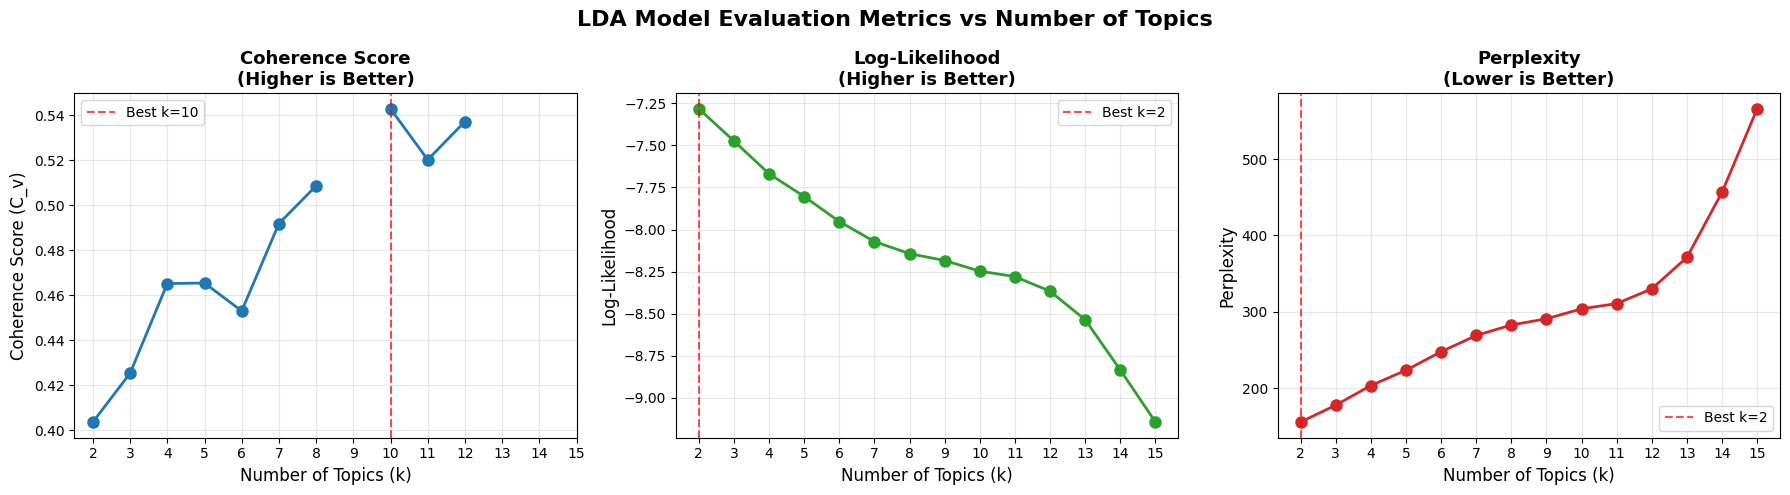

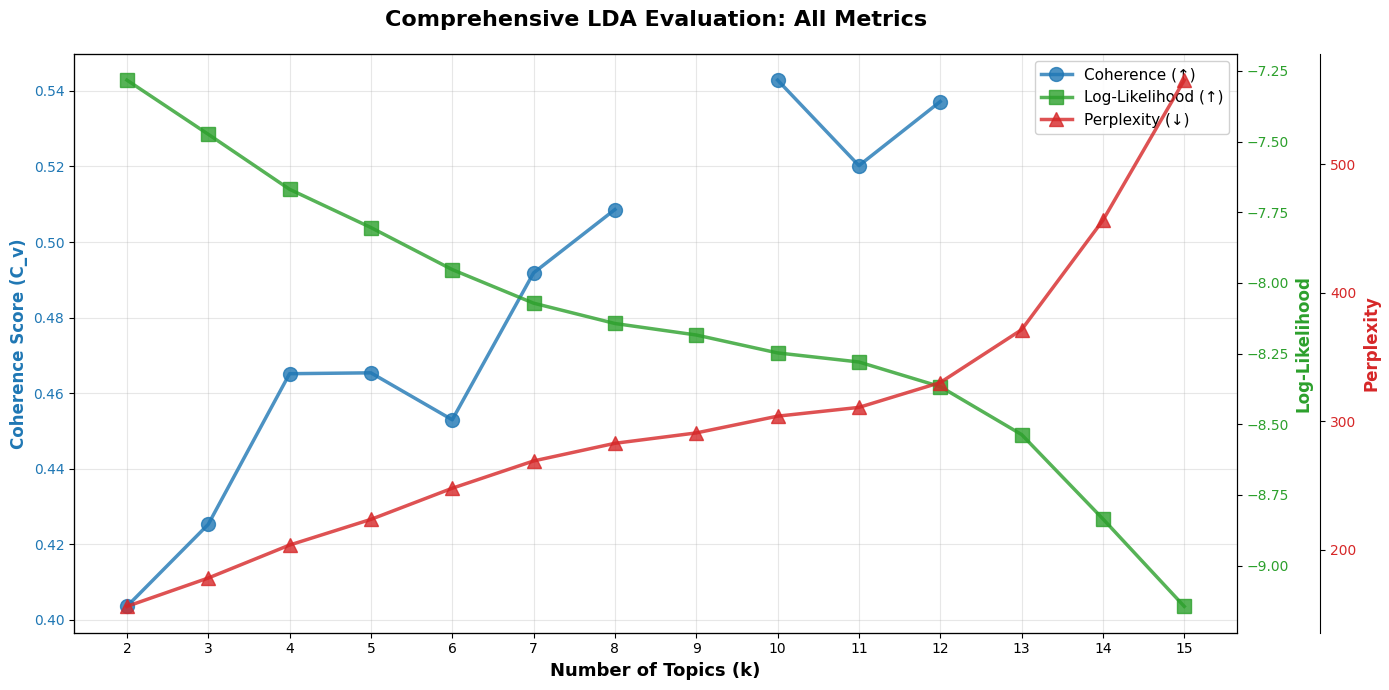


FINAL EVALUATION ON TEST SET

Final Model (k=10) Performance on Test Set:
  ✓ Coherence (C_v):    0.5329
  ✓ Log-Likelihood:     -8.3180
  ✓ Perplexity:         319.1286

TOP 10 WORDS PER TOPIC (k=10)

Topic #1:
  company, say, contract, finland, order, new, value, group, total, include

Topic #2:
  service, business, market, company, product, use, operation, customer, nokia, network

Topic #3:
  pct, building, price, service, take, president, operator, mobile, application, company

Topic #4:
  investment, company, sign, finland, finnish, development, industry, telecom, property, produce

Topic #5:
  share, oyj, finnish, say, today, percent, million, capital, hel, maker

Topic #6:
  company, expect, sale, ceo, financial, report, lead, result, group, growth

Topic #7:
  bank, decrease, nordic, swedish, group, level, nokia, small, nordea, performance

Topic #8:
  eur, net, profit, sale, million, mln, quarter, period, euro, operating

Topic #9:
  share, per, board, shareholder, cash, dir

In [ ]:
# @title
import nltk
import numpy as np
import pandas as pd
from gensim.corpora import Dictionary
from gensim.models import LdaMulticore, CoherenceModel
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- 1. LOAD DATA ---
# Assuming df is already loaded
df.dropna(subset=["cleaned_text"], inplace=True)

# --- 2. SPLIT DATA ---
train_docs, temp_docs = train_test_split(df["cleaned_text"], test_size=0.3, random_state=42)
val_docs, test_docs = train_test_split(temp_docs, test_size=0.5, random_state=42)

print(f"Dataset Split:")
print(f"  Training: {len(train_docs)} documents")
print(f"  Validation: {len(val_docs)} documents")
print(f"  Test: {len(test_docs)} documents\n")

# --- 3. TOKENIZE ---
train_texts = [nltk.word_tokenize(doc.lower()) for doc in train_docs]
val_texts = [nltk.word_tokenize(doc.lower()) for doc in val_docs]
test_texts = [nltk.word_tokenize(doc.lower()) for doc in test_docs]

# --- 4. CREATE DICTIONARY & CORPUS ---
train_dictionary = Dictionary(train_texts)
print(f"Dictionary before filtering: {len(train_dictionary)} unique tokens")

# Filter extremes - keep tokens appearing in at least 3 docs but no more than 80% of docs
train_dictionary.filter_extremes(no_below=3, no_above=0.8, keep_n=None)
print(f"Dictionary after filtering: {len(train_dictionary)} unique tokens\n")

# Create corpus
train_corpus = [train_dictionary.doc2bow(text) for text in train_texts]
val_corpus = [train_dictionary.doc2bow(text) for text in val_texts]
test_corpus = [train_dictionary.doc2bow(text) for text in test_texts]

# --- 5. LDA HYPERPARAMETER TUNING ---
min_topics = 2
max_topics = 15  # Expanded range for better tuning

# Storage for metrics
results = []
coherence_scores = []
perplexity_scores = []
log_likelihood_scores = []
models = {}

print("=" * 80)
print("STARTING HYPERPARAMETER TUNING")
print("=" * 80)

for k in range(min_topics, max_topics + 1):
    print(f"\n{'='*80}")
    print(f"Training LDA with {k} topics...")
    print(f"{'='*80}")

    # Train LDA model with optimized parameters
    lda_model = LdaMulticore(
        corpus=train_corpus,
        id2word=train_dictionary,
        num_topics=k,
        passes=20,              # Number of passes through the corpus
        iterations=400,         # Max iterations within each document
        random_state=42,
        chunksize=100,          # Number of documents to process at a time
        workers=3,              # Number of worker processes
        eval_every=10,          # Evaluate perplexity every N chunks
        alpha='asymmetric',     # Asymmetric prior - some topics more likely
        eta='auto',             # Let the model learn eta (beta) from data
        decay=0.5,              # Learning rate decay
        offset=1.0,             # Downweight early iterations
        per_word_topics=True,   # Return topic distribution per word
        minimum_probability=0.01,
        minimum_phi_value=0.01
    )

    # Store model
    models[k] = lda_model

    # --- CALCULATE COHERENCE (C_v) ---
    # C_v is best for interpretability
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=val_texts,
        dictionary=train_dictionary,
        coherence='c_v',
        processes=1
    )
    coherence_cv = coherence_model.get_coherence()

    # --- CALCULATE LOG-LIKELIHOOD ---
    # Higher log-likelihood = better fit
    log_likelihood = lda_model.log_perplexity(val_corpus)

    # --- CALCULATE PERPLEXITY ---
    # Lower perplexity = better generalization
    # Perplexity = exp(-log_likelihood)
    perplexity = np.exp2(-log_likelihood)

    # Store results
    coherence_scores.append(coherence_cv)
    log_likelihood_scores.append(log_likelihood)
    perplexity_scores.append(perplexity)

    results.append({
        'num_topics': k,
        'coherence_cv': coherence_cv,
        'log_likelihood': log_likelihood,
        'perplexity': perplexity
    })

    print(f"\n📊 Metrics for k={k}:")
    print(f"  ✓ Coherence (C_v):    {coherence_cv:.4f}  [Higher is better]")
    print(f"  ✓ Log-Likelihood:     {log_likelihood:.4f}  [Higher is better]")
    print(f"  ✓ Perplexity:         {perplexity:.4f}  [Lower is better]")

# --- 6. CREATE RESULTS DATAFRAME ---
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("SUMMARY OF ALL MODELS")
print("="*80)
print(results_df.to_string(index=False))

# --- 7. FIND OPTIMAL K ---
best_k_coherence = results_df.loc[results_df['coherence_cv'].idxmax(), 'num_topics']
best_k_likelihood = results_df.loc[results_df['log_likelihood'].idxmax(), 'num_topics']
best_k_perplexity = results_df.loc[results_df['perplexity'].idxmin(), 'num_topics']

print("\n" + "="*80)
print("OPTIMAL NUMBER OF TOPICS")
print("="*80)
print(f"Based on Coherence:      k = {best_k_coherence}")
print(f"Based on Log-Likelihood: k = {best_k_likelihood}")
print(f"Based on Perplexity:     k = {best_k_perplexity}")

# --- 8. VISUALIZE METRICS ---
x = range(min_topics, max_topics + 1)

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('LDA Model Evaluation Metrics vs Number of Topics', fontsize=16, fontweight='bold')

# Plot 1: Coherence Score (Higher is Better)
axes[0].plot(x, coherence_scores, 'o-', color='tab:blue', linewidth=2, markersize=8)
axes[0].axvline(x=best_k_coherence, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k_coherence}')
axes[0].set_xlabel('Number of Topics (k)', fontsize=12)
axes[0].set_ylabel('Coherence Score (C_v)', fontsize=12)
axes[0].set_title('Coherence Score\n(Higher is Better)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_xticks(x)

# Plot 2: Log-Likelihood (Higher is Better)
axes[1].plot(x, log_likelihood_scores, 'o-', color='tab:green', linewidth=2, markersize=8)
axes[1].axvline(x=best_k_likelihood, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k_likelihood}')
axes[1].set_xlabel('Number of Topics (k)', fontsize=12)
axes[1].set_ylabel('Log-Likelihood', fontsize=12)
axes[1].set_title('Log-Likelihood\n(Higher is Better)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xticks(x)

# Plot 3: Perplexity (Lower is Better)
axes[2].plot(x, perplexity_scores, 'o-', color='tab:red', linewidth=2, markersize=8)
axes[2].axvline(x=best_k_perplexity, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k_perplexity}')
axes[2].set_xlabel('Number of Topics (k)', fontsize=12)
axes[2].set_ylabel('Perplexity', fontsize=12)
axes[2].set_title('Perplexity\n(Lower is Better)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].set_xticks(x)

plt.tight_layout()
plt.show()

# --- 9. COMBINED PLOT WITH DUAL Y-AXES ---
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Coherence on primary y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Number of Topics (k)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Coherence Score (C_v)', color=color1, fontsize=12, fontweight='bold')
line1 = ax1.plot(x, coherence_scores, 'o-', color=color1, linewidth=2.5,
                 markersize=10, label='Coherence (↑)', alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(x)

# Create second y-axis for Log-Likelihood
ax2 = ax1.twinx()
color2 = 'tab:green'
ax2.set_ylabel('Log-Likelihood', color=color2, fontsize=12, fontweight='bold')
line2 = ax2.plot(x, log_likelihood_scores, 's-', color=color2, linewidth=2.5,
                 markersize=10, label='Log-Likelihood (↑)', alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color2)

# Create third y-axis for Perplexity
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color3 = 'tab:red'
ax3.set_ylabel('Perplexity', color=color3, fontsize=12, fontweight='bold')
line3 = ax3.plot(x, perplexity_scores, '^-', color=color3, linewidth=2.5,
                 markersize=10, label='Perplexity (↓)', alpha=0.8)
ax3.tick_params(axis='y', labelcolor=color3)

# Combine legends
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best', fontsize=11, framealpha=0.9)

plt.title('Comprehensive LDA Evaluation: All Metrics', fontsize=16, fontweight='bold', pad=20)
fig.tight_layout()
plt.show()

# --- 10. EVALUATE BEST MODEL ON TEST SET ---
print("\n" + "="*80)
print("FINAL EVALUATION ON TEST SET")
print("="*80)

final_k = best_k_coherence  # Using coherence as primary metric
best_model = models[final_k]

# Test set metrics
test_coherence = CoherenceModel(
    model=best_model,
    texts=test_texts,
    dictionary=train_dictionary,
    coherence='c_v',
    processes=1
).get_coherence()

test_log_likelihood = best_model.log_perplexity(test_corpus)
test_perplexity = np.exp2(-test_log_likelihood)

print(f"\nFinal Model (k={final_k}) Performance on Test Set:")
print(f"  ✓ Coherence (C_v):    {test_coherence:.4f}")
print(f"  ✓ Log-Likelihood:     {test_log_likelihood:.4f}")
print(f"  ✓ Perplexity:         {test_perplexity:.4f}")

# --- 11. DISPLAY TOP WORDS PER TOPIC ---
print("\n" + "="*80)
print(f"TOP 10 WORDS PER TOPIC (k={final_k})")
print("="*80)

for idx, topic in best_model.print_topics(num_topics=final_k, num_words=10):
    print(f"\nTopic #{idx + 1}:")
    # Parse and clean the topic words
    words = [word.split('*')[1].replace('"', '').strip() for word in topic.split('+')]
    print(f"  {', '.join(words)}")

print("\n" + "="*80)
print("TUNING COMPLETE!")
print("="*80)

Dataset Split:
  Training: 3391 documents
  Validation: 727 documents
  Test: 727 documents

Dictionary before filtering: 6312 unique tokens
Dictionary after filtering: 2035 unique tokens

Training corpus: 3391 docs, 33757 total words
Validation corpus: 727 docs, 7112 total words

STARTING HYPERPARAMETER TUNING

Training LDA with 2 topics...

📊 Metrics for k=2:
  ✓ Coherence (C_v):      0.4381  [Higher is better]
  ✓ Log-Likelihood:       -72.1512  [Higher is better]
  ✓ Perplexity:           166.0423  [Lower is better]

Training LDA with 3 topics...

📊 Metrics for k=3:
  ✓ Coherence (C_v):      0.4002  [Higher is better]
  ✓ Log-Likelihood:       -74.9187  [Higher is better]
  ✓ Perplexity:           202.0103  [Lower is better]

Training LDA with 4 topics...

📊 Metrics for k=4:
  ✓ Coherence (C_v):      0.4105  [Higher is better]
  ✓ Log-Likelihood:       -77.2437  [Higher is better]
  ✓ Perplexity:           238.1947  [Lower is better]

Training LDA with 5 topics...

📊 Metrics for k=

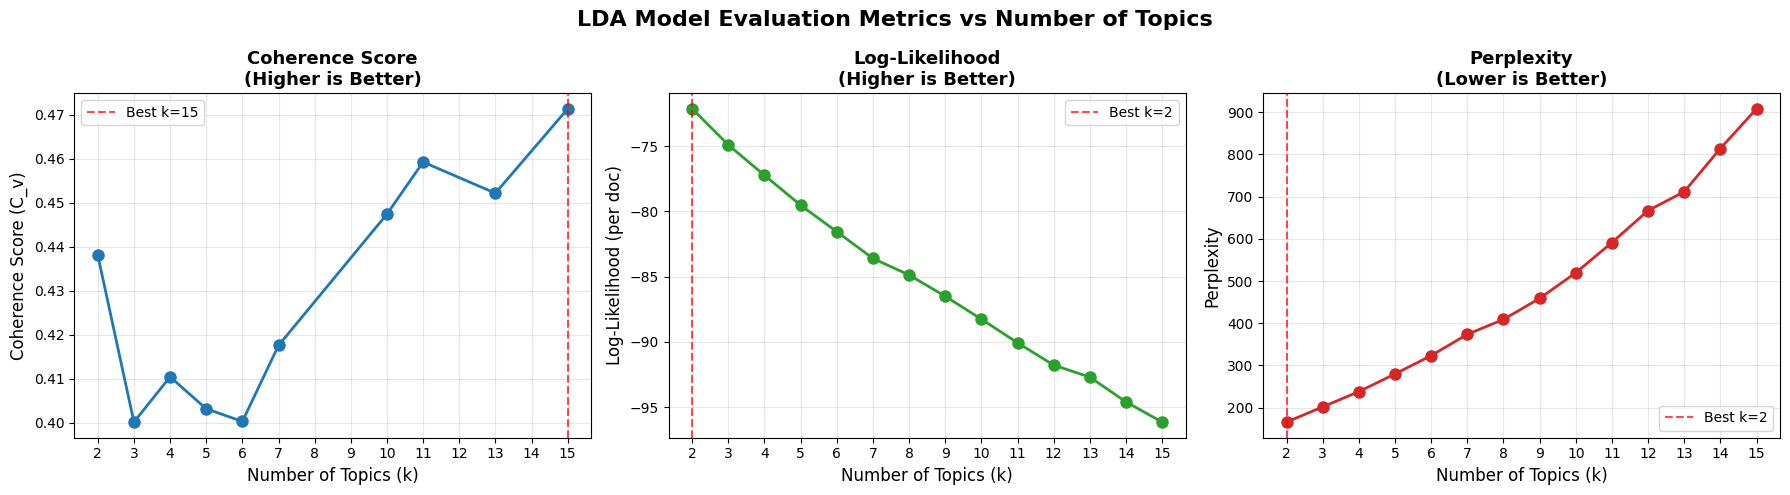

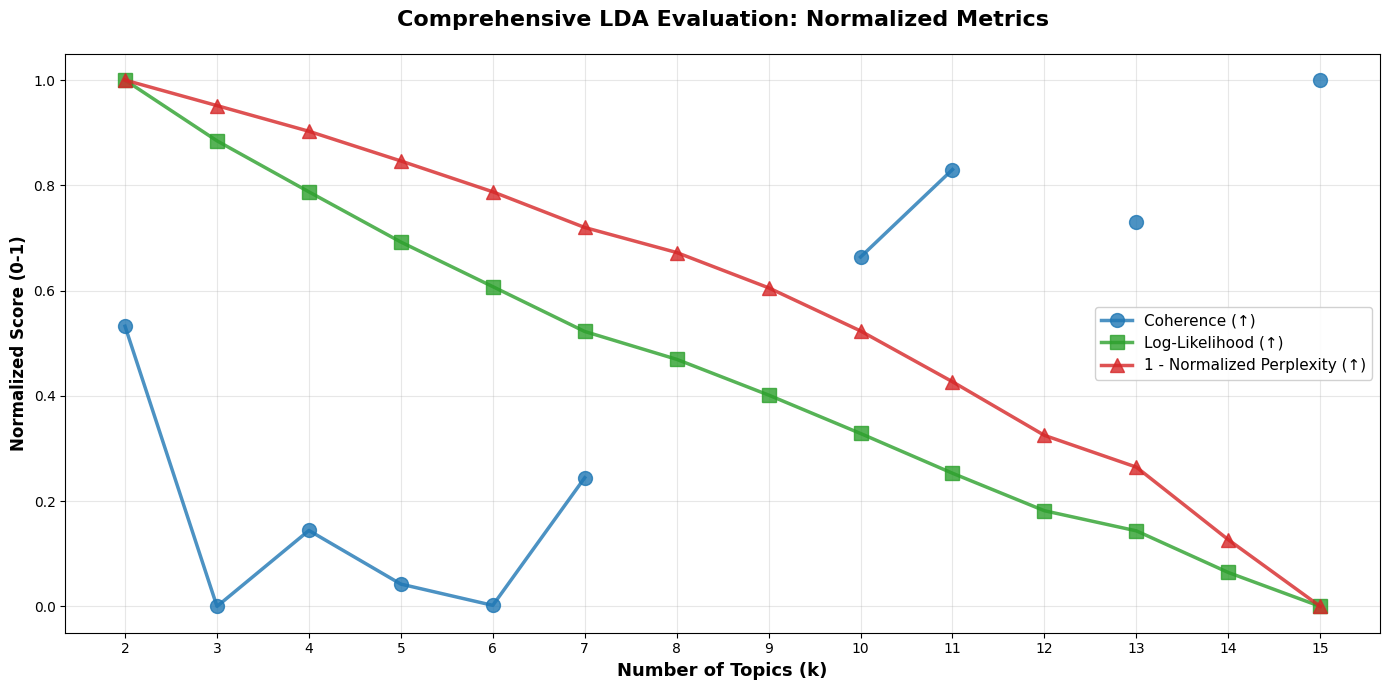


FINAL EVALUATION ON TEST SET

Final Model (k=15) Performance on Test Set:
  ✓ Coherence (C_v):      0.4642
  ✓ Log-Likelihood:       -94.6860
  ✓ Perplexity:           974.4643

TOP 10 WORDS PER TOPIC (k=15)

Topic #1:
  say, bank, service, company, include, unit, contract, construction, area, agreement

Topic #2:
  company, nokia, service, business, mobile, market, customer, technology, new, say

Topic #3:
  company, pct, brand, inc, system, helsinki, mobile, finnish, phone, group

Topic #4:
  company, plant, also, finland, use, build, russia, new, facility, plan

Topic #5:
  company, business, finnish, say, finland, part, production, unit, market, operation

Topic #6:
  say, company, group, finnish, finland, business, million, result, service, medium

Topic #7:
  company, finland, pct, stora, helsinki, enso, also, year, solution, develop

Topic #8:
  quarter, eur, finnish, net, say, profit, first, loss, oyj, today

Topic #9:
  company, financial, group, sale, report, disclose, take,

In [ ]:
# @title
import nltk
import numpy as np
import pandas as pd
from gensim.corpora import Dictionary
from gensim.models import LdaMulticore, CoherenceModel
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- 1. LOAD DATA ---
# Assuming df is already loaded
df.dropna(subset=["cleaned_text"], inplace=True)

# --- 2. SPLIT DATA ---
train_docs, temp_docs = train_test_split(df["cleaned_text"], test_size=0.3, random_state=42)
val_docs, test_docs = train_test_split(temp_docs, test_size=0.5, random_state=42)

print(f"Dataset Split:")
print(f"  Training: {len(train_docs)} documents")
print(f"  Validation: {len(val_docs)} documents")
print(f"  Test: {len(test_docs)} documents\n")

# --- 3. TOKENIZE ---
train_texts = [nltk.word_tokenize(doc.lower()) for doc in train_docs]
val_texts = [nltk.word_tokenize(doc.lower()) for doc in val_docs]
test_texts = [nltk.word_tokenize(doc.lower()) for doc in test_docs]

# --- 4. CREATE DICTIONARY & CORPUS ---
train_dictionary = Dictionary(train_texts)
print(f"Dictionary before filtering: {len(train_dictionary)} unique tokens")

# Filter extremes - keep tokens appearing in at least 3 docs but no more than 80% of docs
train_dictionary.filter_extremes(no_below=3, no_above=0.8, keep_n=None)
print(f"Dictionary after filtering: {len(train_dictionary)} unique tokens\n")

# Compute document statistics for proper perplexity calculation
train_corpus = [train_dictionary.doc2bow(text) for text in train_texts]
val_corpus = [train_dictionary.doc2bow(text) for text in val_texts]
test_corpus = [train_dictionary.doc2bow(text) for text in test_texts]

# Calculate total word counts
def get_corpus_word_count(corpus):
    """Calculate total number of words in corpus"""
    return sum(count for doc in corpus for _, count in doc)

train_word_count = get_corpus_word_count(train_corpus)
val_word_count = get_corpus_word_count(val_corpus)

print(f"Training corpus: {len(train_corpus)} docs, {train_word_count} total words")
print(f"Validation corpus: {len(val_corpus)} docs, {val_word_count} total words\n")

# --- 5. LDA HYPERPARAMETER TUNING ---
min_topics = 2
max_topics = 15

# Storage for metrics
results = []
coherence_scores = []
perplexity_scores = []
log_likelihood_scores = []
models = {}

print("=" * 80)
print("STARTING HYPERPARAMETER TUNING")
print("=" * 80)

for k in range(min_topics, max_topics + 1):
    print(f"\n{'='*80}")
    print(f"Training LDA with {k} topics...")
    print(f"{'='*80}")

    # Train LDA model with optimized parameters
    lda_model = LdaMulticore(
        corpus=train_corpus,
        id2word=train_dictionary,
        num_topics=k,
        passes=10,              # Number of passes through the corpus
        iterations=100,         # Max iterations within each document
        random_state=42,
        chunksize=2000,         # Larger chunks for stability
        workers=3,              # Number of worker processes
        eval_every=None,        # Don't evaluate during training
        alpha='symmetric',      # Symmetric Dirichlet prior (safer default)
        eta=None,               # Use default symmetric prior (1/num_topics)
        decay=0.5,              # Learning rate decay
        offset=1.0,             # Downweight early iterations
        per_word_topics=False,  # Disable for faster training
        minimum_probability=0.0 # Don't filter topics
    )

    # Store model
    models[k] = lda_model

    # --- CALCULATE COHERENCE (C_v) ---
    try:
        coherence_model = CoherenceModel(
            model=lda_model,
            texts=val_texts,
            dictionary=train_dictionary,
            coherence='c_v',
            processes=1
        )
        coherence_cv = coherence_model.get_coherence()
    except:
        coherence_cv = np.nan
        print("  ⚠️  Coherence calculation failed (likely due to topic collapse)")

    # --- CALCULATE LOG-LIKELIHOOD (Correct Method) ---
    # The bound() method returns the variational bound (ELBO)
    # which is a lower bound on the log-likelihood
    # Higher values = better
    try:
        log_likelihood_bound = lda_model.bound(val_corpus)
        # Normalize by number of documents for comparison
        log_likelihood_per_doc = log_likelihood_bound / len(val_corpus)
    except:
        log_likelihood_per_doc = np.nan

    # --- CALCULATE PERPLEXITY (Correct Method) ---
    # Perplexity = exp(-log_likelihood / word_count)
    # Lower perplexity = better generalization
    try:
        # Method 1: Using built-in log_perplexity (returns per-word bound)
        per_word_bound = lda_model.log_perplexity(val_corpus)
        # This is already negative log-likelihood per word
        # Perplexity = 2^(-per_word_bound)
        perplexity = 2**(-per_word_bound)

        # Alternative calculation for verification
        # perplexity_alt = np.exp(-log_likelihood_bound / val_word_count)
    except:
        perplexity = np.nan

    # Store results
    coherence_scores.append(coherence_cv)
    log_likelihood_scores.append(log_likelihood_per_doc)
    perplexity_scores.append(perplexity)

    results.append({
        'num_topics': k,
        'coherence_cv': coherence_cv,
        'log_likelihood': log_likelihood_per_doc,
        'perplexity': perplexity
    })

    print(f"\n📊 Metrics for k={k}:")
    print(f"  ✓ Coherence (C_v):      {coherence_cv:.4f}  [Higher is better]")
    print(f"  ✓ Log-Likelihood:       {log_likelihood_per_doc:.4f}  [Higher is better]")
    print(f"  ✓ Perplexity:           {perplexity:.4f}  [Lower is better]")

# --- 6. CREATE RESULTS DATAFRAME ---
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("SUMMARY OF ALL MODELS")
print("="*80)
print(results_df.to_string(index=False))

# --- 7. FIND OPTIMAL K (Excluding NaN values) ---
results_df_clean = results_df.dropna()

if len(results_df_clean) > 0:
    best_k_coherence = int(results_df_clean.loc[results_df_clean['coherence_cv'].idxmax(), 'num_topics'])
    best_k_likelihood = int(results_df_clean.loc[results_df_clean['log_likelihood'].idxmax(), 'num_topics'])
    best_k_perplexity = int(results_df_clean.loc[results_df_clean['perplexity'].idxmin(), 'num_topics'])

    print("\n" + "="*80)
    print("OPTIMAL NUMBER OF TOPICS")
    print("="*80)
    print(f"Based on Coherence:      k = {best_k_coherence}")
    print(f"Based on Log-Likelihood: k = {best_k_likelihood}")
    print(f"Based on Perplexity:     k = {best_k_perplexity}")
else:
    print("\n⚠️  All models failed to produce valid metrics!")
    best_k_coherence = min_topics

# --- 8. VISUALIZE METRICS ---
x = list(range(min_topics, max_topics + 1))

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('LDA Model Evaluation Metrics vs Number of Topics', fontsize=16, fontweight='bold')

# Plot 1: Coherence Score (Higher is Better)
valid_coherence = [(i, c) for i, c in zip(x, coherence_scores) if not np.isnan(c)]
if valid_coherence:
    x_coh, y_coh = zip(*valid_coherence)
    axes[0].plot(x_coh, y_coh, 'o-', color='tab:blue', linewidth=2, markersize=8)
    if best_k_coherence in x_coh:
        axes[0].axvline(x=best_k_coherence, color='red', linestyle='--', alpha=0.7,
                        label=f'Best k={best_k_coherence}')
axes[0].set_xlabel('Number of Topics (k)', fontsize=12)
axes[0].set_ylabel('Coherence Score (C_v)', fontsize=12)
axes[0].set_title('Coherence Score\n(Higher is Better)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_xticks(x)

# Plot 2: Log-Likelihood (Higher is Better)
valid_ll = [(i, ll) for i, ll in zip(x, log_likelihood_scores) if not np.isnan(ll)]
if valid_ll:
    x_ll, y_ll = zip(*valid_ll)
    axes[1].plot(x_ll, y_ll, 'o-', color='tab:green', linewidth=2, markersize=8)
    if best_k_likelihood in x_ll:
        axes[1].axvline(x=best_k_likelihood, color='red', linestyle='--', alpha=0.7,
                        label=f'Best k={best_k_likelihood}')
axes[1].set_xlabel('Number of Topics (k)', fontsize=12)
axes[1].set_ylabel('Log-Likelihood (per doc)', fontsize=12)
axes[1].set_title('Log-Likelihood\n(Higher is Better)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xticks(x)

# Plot 3: Perplexity (Lower is Better)
valid_perp = [(i, p) for i, p in zip(x, perplexity_scores) if not np.isnan(p)]
if valid_perp:
    x_perp, y_perp = zip(*valid_perp)
    axes[2].plot(x_perp, y_perp, 'o-', color='tab:red', linewidth=2, markersize=8)
    if best_k_perplexity in x_perp:
        axes[2].axvline(x=best_k_perplexity, color='red', linestyle='--', alpha=0.7,
                        label=f'Best k={best_k_perplexity}')
axes[2].set_xlabel('Number of Topics (k)', fontsize=12)
axes[2].set_ylabel('Perplexity', fontsize=12)
axes[2].set_title('Perplexity\n(Lower is Better)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].set_xticks(x)

plt.tight_layout()
plt.show()

# --- 9. COMBINED PLOT WITH NORMALIZED METRICS ---
fig, ax1 = plt.subplots(figsize=(14, 7))

# Normalize metrics to [0, 1] for better visualization
def normalize(scores):
    """Min-max normalization"""
    valid_scores = [s for s in scores if not np.isnan(s)]
    if not valid_scores:
        return scores
    min_s, max_s = min(valid_scores), max(valid_scores)
    if max_s - min_s == 0:
        return scores
    return [(s - min_s) / (max_s - min_s) if not np.isnan(s) else np.nan for s in scores]

norm_coherence = normalize(coherence_scores)
norm_likelihood = normalize(log_likelihood_scores)
# Invert perplexity for visualization (so higher is better for all)
norm_perplexity = [1 - p for p in normalize(perplexity_scores)]

# Plot all metrics
ax1.plot(x, norm_coherence, 'o-', color='tab:blue', linewidth=2.5,
         markersize=10, label='Coherence (↑)', alpha=0.8)
ax1.plot(x, norm_likelihood, 's-', color='tab:green', linewidth=2.5,
         markersize=10, label='Log-Likelihood (↑)', alpha=0.8)
ax1.plot(x, norm_perplexity, '^-', color='tab:red', linewidth=2.5,
         markersize=10, label='1 - Normalized Perplexity (↑)', alpha=0.8)

ax1.set_xlabel('Number of Topics (k)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Normalized Score (0-1)', fontsize=12, fontweight='bold')
ax1.set_title('Comprehensive LDA Evaluation: Normalized Metrics', fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(x)
ax1.legend(loc='best', fontsize=11, framealpha=0.9)

fig.tight_layout()
plt.show()

# --- 10. EVALUATE BEST MODEL ON TEST SET ---
print("\n" + "="*80)
print("FINAL EVALUATION ON TEST SET")
print("="*80)

final_k = best_k_coherence  # Using coherence as primary metric
best_model = models[final_k]

# Test set metrics
try:
    test_coherence = CoherenceModel(
        model=best_model,
        texts=test_texts,
        dictionary=train_dictionary,
        coherence='c_v',
        processes=1
    ).get_coherence()
except:
    test_coherence = np.nan

test_log_likelihood = best_model.bound(test_corpus) / len(test_corpus)
test_per_word_bound = best_model.log_perplexity(test_corpus)
test_perplexity = 2**(-test_per_word_bound)

print(f"\nFinal Model (k={final_k}) Performance on Test Set:")
print(f"  ✓ Coherence (C_v):      {test_coherence:.4f}")
print(f"  ✓ Log-Likelihood:       {test_log_likelihood:.4f}")
print(f"  ✓ Perplexity:           {test_perplexity:.4f}")

# --- 11. DISPLAY TOP WORDS PER TOPIC ---
print("\n" + "="*80)
print(f"TOP 10 WORDS PER TOPIC (k={final_k})")
print("="*80)

for idx, topic in best_model.print_topics(num_topics=final_k, num_words=10):
    print(f"\nTopic #{idx + 1}:")
    # Parse and clean the topic words
    words = [word.split('*')[1].replace('"', '').strip() for word in topic.split('+')]
    print(f"  {', '.join(words)}")

print("\n" + "="*80)
print("TUNING COMPLETE!")
print("="*80)

# --- 12. ADDITIONAL DIAGNOSTIC INFORMATION ---
print("\n" + "="*80)
print("DIAGNOSTIC INFORMATION")
print("="*80)
print("\n⚠️  IMPORTANT NOTES ON METRICS:")
print("  • Log-Likelihood should INCREASE with more topics (better fit)")
print("  • Perplexity should DECREASE with more topics (better generalization)")
print("  • Coherence should peak at optimal k (best interpretability)")
print("  • If trends are inverted, check corpus size and model convergence")

Dataset Split:
  Training: 3391 documents
  Validation: 727 documents
  Test: 727 documents

Dictionary before filtering: 6312 unique tokens
Dictionary after filtering: 1339 unique tokens

Training corpus: 3391 docs, 31287 words
Validation corpus: 727 docs, 6656 words

STARTING HYPERPARAMETER TUNING WITH OPTIMIZED SETTINGS

Training LDA with 2 topics...

📊 TRAINING SET Metrics (k=2):
  ✓ Log-Likelihood (per word): -45.0206
  ✓ Perplexity:                0.0000

📊 VALIDATION SET Metrics (k=2):
  ✓ Coherence (C_v):           0.3215
  ✓ Log-Likelihood (per word): -42.8546
  ✓ Perplexity:                0.0000

Training LDA with 3 topics...

📊 TRAINING SET Metrics (k=3):
  ✓ Log-Likelihood (per word): -45.2683
  ✓ Perplexity:                0.0000

📊 VALIDATION SET Metrics (k=3):
  ✓ Coherence (C_v):           0.4485
  ✓ Log-Likelihood (per word): -43.1058
  ✓ Perplexity:                0.0000

Training LDA with 4 topics...

📊 TRAINING SET Metrics (k=4):
  ✓ Log-Likelihood (per word): -45.

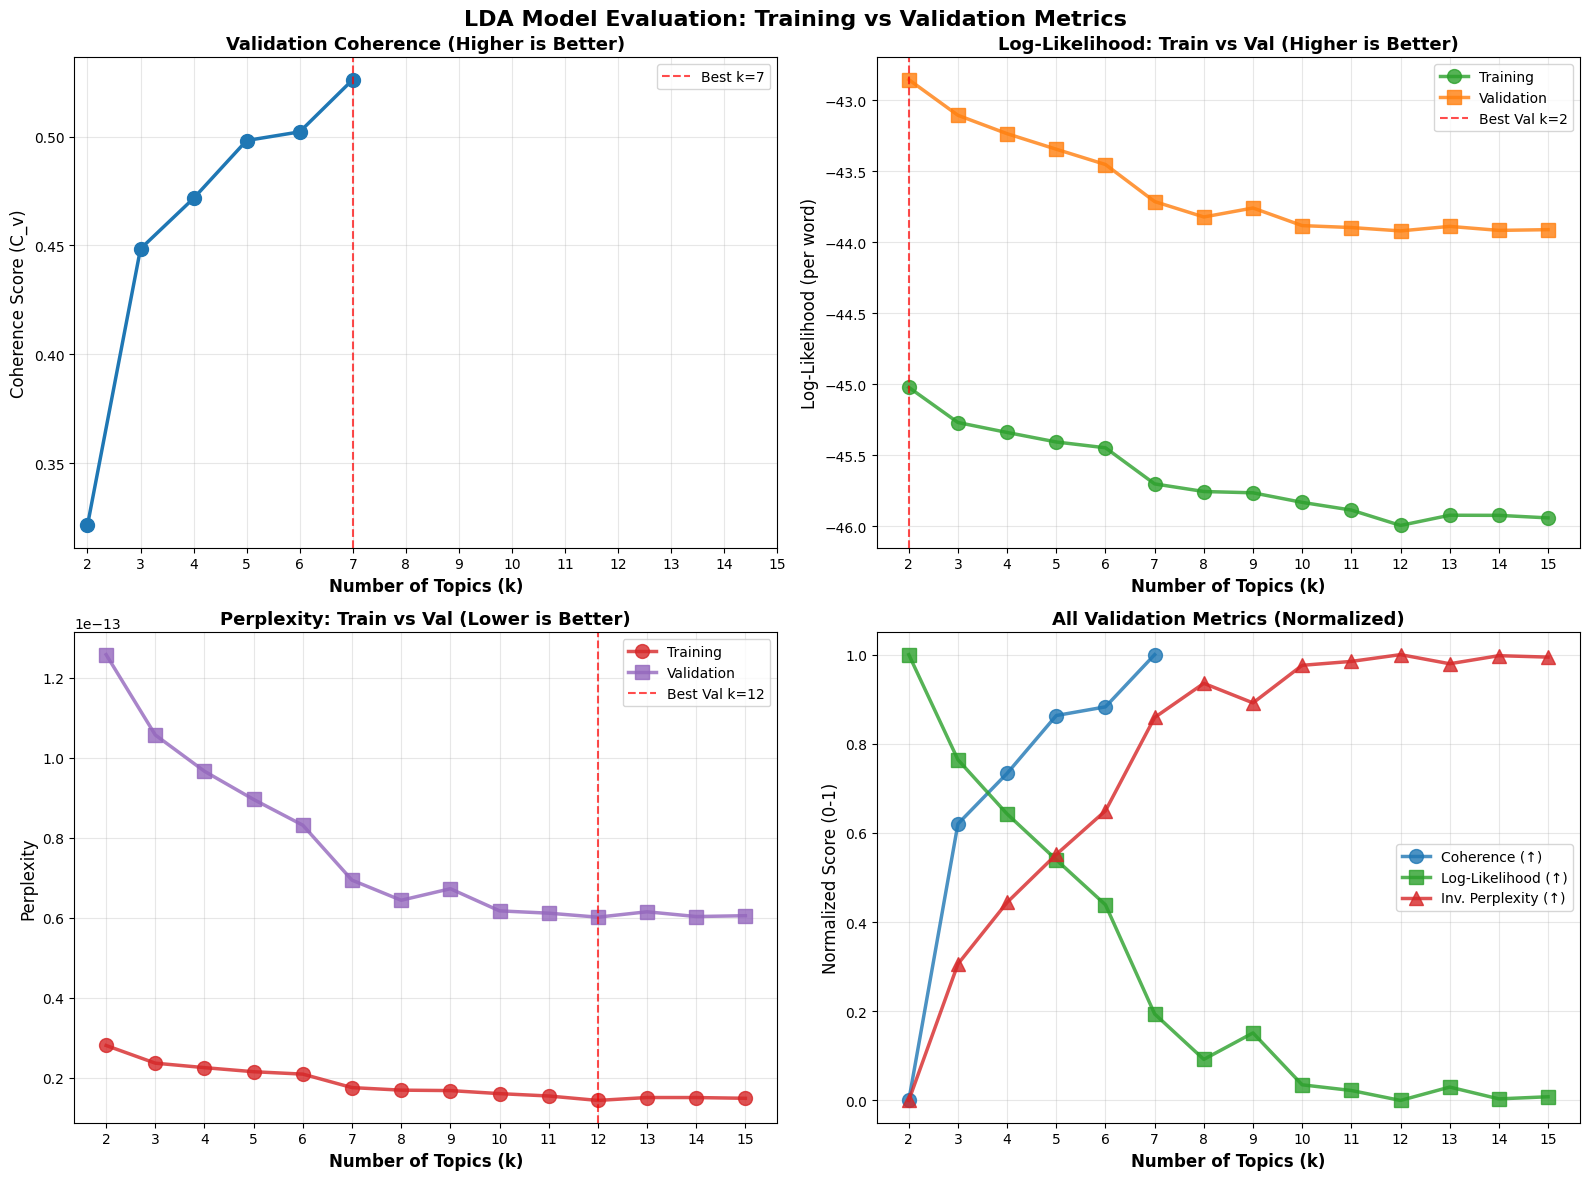


FINAL EVALUATION ON TEST SET

Final Model (k=7) Performance on Test Set:
  ✓ Coherence (C_v):           0.5347
  ✓ Log-Likelihood (per word): -45.1876
  ✓ Perplexity:                0.0000

TOP 10 WORDS PER TOPIC (k=7)

Topic #1:
  service, business, include, order, technology, mobile, make, customer, provide, base

Topic #2:
  say, market, contract, solution, expect, nokia, investment, today, percent, project

Topic #3:
  share, mln, year, total, euro, oyj, per, value, stock, capital

Topic #4:
  eur, million, profit, net, quarter, period, operating, increase, first, loss

Topic #5:
  finnish, finland, group, helsinki, corporation, agreement, facility, construction, pct, sell

Topic #6:
  new, also, product, plant, use, production, well, would, development, one

Topic #7:
  company, sale, operation, system, report, accord, result, unit, financial, price

DIAGNOSTIC ANALYSIS

📈 Expected Behavior:
  TRAINING SET:
    • Log-Likelihood should INCREASE (less negative)
    • Perplexity sho

In [ ]:
import nltk
import numpy as np
import pandas as pd
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- 1. LOAD DATA ---
df.dropna(subset=["cleaned_text"], inplace=True)

# --- 2. SPLIT DATA ---
train_docs, temp_docs = train_test_split(df["cleaned_text"], test_size=0.3, random_state=42)
val_docs, test_docs = train_test_split(temp_docs, test_size=0.5, random_state=42)

print(f"Dataset Split:")
print(f"  Training: {len(train_docs)} documents")
print(f"  Validation: {len(val_docs)} documents")
print(f"  Test: {len(test_docs)} documents\n")

# --- 3. TOKENIZE ---
train_texts = [nltk.word_tokenize(doc.lower()) for doc in train_docs]
val_texts = [nltk.word_tokenize(doc.lower()) for doc in val_docs]
test_texts = [nltk.word_tokenize(doc.lower()) for doc in test_docs]

# --- 4. CREATE DICTIONARY & CORPUS ---
train_dictionary = Dictionary(train_texts)
print(f"Dictionary before filtering: {len(train_dictionary)} unique tokens")

# More conservative filtering for small corpus
train_dictionary.filter_extremes(no_below=5, no_above=0.7, keep_n=None)
print(f"Dictionary after filtering: {len(train_dictionary)} unique tokens\n")

# Create corpora
train_corpus = [train_dictionary.doc2bow(text) for text in train_texts]
val_corpus = [train_dictionary.doc2bow(text) for text in val_texts]
test_corpus = [train_dictionary.doc2bow(text) for text in test_texts]

# Calculate word counts
def get_corpus_word_count(corpus):
    return sum(count for doc in corpus for _, count in doc)

train_word_count = get_corpus_word_count(train_corpus)
val_word_count = get_corpus_word_count(val_corpus)

print(f"Training corpus: {len(train_corpus)} docs, {train_word_count} words")
print(f"Validation corpus: {len(val_corpus)} docs, {val_word_count} words\n")

# --- 5. HYPERPARAMETER TUNING WITH PROPER SETTINGS ---
min_topics = 2
max_topics = 15

results = []
models = {}

print("=" * 90)
print("STARTING HYPERPARAMETER TUNING WITH OPTIMIZED SETTINGS")
print("=" * 90)

for k in range(min_topics, max_topics + 1):
    print(f"\n{'='*90}")
    print(f"Training LDA with {k} topics...")
    print(f"{'='*90}")

    # CRITICAL: Use optimized hyperparameters based on LDA theory
    # Alpha: Document-topic density (lower = fewer topics per doc)
    # Eta (Beta): Topic-word density (lower = fewer words per topic)

    # Calculate optimized priors
    alpha_prior = 50.0 / k  # Asymmetric prior scaled by number of topics
    eta_prior = 0.01        # Sparse topics (fewer words per topic)

    # Train with STANDARD LdaModel (more stable than Multicore)
    lda_model = LdaModel(
        corpus=train_corpus,
        id2word=train_dictionary,
        num_topics=k,
        random_state=42,
        chunksize=100,
        passes=50,              # More passes for convergence
        iterations=200,         # More iterations per document
        alpha=alpha_prior,      # Optimized alpha
        eta=eta_prior,          # Sparse topics
        update_every=1,         # Update model after each chunk
        eval_every=10,          # Log perplexity every 10 chunks
        per_word_topics=False,
        minimum_probability=0.01,
        callbacks=None
    )

    models[k] = lda_model

    # ============================================================
    # EVALUATE ON TRAINING SET (should show improvement)
    # ============================================================
    train_perplexity_raw = lda_model.log_perplexity(train_corpus)
    train_perplexity = np.exp2(train_perplexity_raw)

    # ============================================================
    # EVALUATE ON VALIDATION SET
    # ============================================================
    val_perplexity_raw = lda_model.log_perplexity(val_corpus)
    val_perplexity = np.exp2(val_perplexity_raw)

    # Calculate proper log-likelihood
    # The bound() gives ELBO which approximates log p(w|model)
    train_ll_total = lda_model.bound(train_corpus)
    val_ll_total = lda_model.bound(val_corpus)

    # Normalize by word count for fair comparison
    train_ll_per_word = train_ll_total / train_word_count
    val_ll_per_word = val_ll_total / val_word_count

    # Calculate coherence
    try:
        coherence_model = CoherenceModel(
            model=lda_model,
            texts=val_texts,
            dictionary=train_dictionary,
            coherence='c_v',
            processes=1
        )
        coherence_cv = coherence_model.get_coherence()
    except Exception as e:
        coherence_cv = np.nan
        print(f"  ⚠️  Coherence failed: {e}")

    # Store results
    results.append({
        'num_topics': k,
        'coherence_cv': coherence_cv,
        'train_ll_per_word': train_ll_per_word,
        'val_ll_per_word': val_ll_per_word,
        'train_perplexity': train_perplexity,
        'val_perplexity': val_perplexity
    })

    print(f"\n📊 TRAINING SET Metrics (k={k}):")
    print(f"  ✓ Log-Likelihood (per word): {train_ll_per_word:.4f}")
    print(f"  ✓ Perplexity:                {train_perplexity:.4f}")

    print(f"\n📊 VALIDATION SET Metrics (k={k}):")
    print(f"  ✓ Coherence (C_v):           {coherence_cv:.4f}")
    print(f"  ✓ Log-Likelihood (per word): {val_ll_per_word:.4f}")
    print(f"  ✓ Perplexity:                {val_perplexity:.4f}")

# --- 6. CREATE RESULTS DATAFRAME ---
results_df = pd.DataFrame(results)

print("\n" + "="*90)
print("SUMMARY OF ALL MODELS")
print("="*90)
print(results_df.to_string(index=False))

# --- 7. FIND OPTIMAL K ---
results_clean = results_df.dropna(subset=['coherence_cv'])

if len(results_clean) > 0:
    best_k_coherence = int(results_clean.loc[results_clean['coherence_cv'].idxmax(), 'num_topics'])
    best_k_val_ll = int(results_df.loc[results_df['val_ll_per_word'].idxmax(), 'num_topics'])
    best_k_val_perp = int(results_df.loc[results_df['val_perplexity'].idxmin(), 'num_topics'])

    print("\n" + "="*90)
    print("OPTIMAL NUMBER OF TOPICS")
    print("="*90)
    print(f"Based on Validation Coherence:      k = {best_k_coherence}")
    print(f"Based on Validation Log-Likelihood: k = {best_k_val_ll}")
    print(f"Based on Validation Perplexity:     k = {best_k_val_perp}")
else:
    best_k_coherence = 2
    best_k_val_ll = 2
    best_k_val_perp = 2

# --- 8. VISUALIZE METRICS (4 plots) ---
x = list(range(min_topics, max_topics + 1))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('LDA Model Evaluation: Training vs Validation Metrics',
             fontsize=16, fontweight='bold')

# Plot 1: Coherence Score
valid_coh = [(i, c) for i, c in zip(x, results_df['coherence_cv']) if not np.isnan(c)]
if valid_coh:
    x_coh, y_coh = zip(*valid_coh)
    axes[0, 0].plot(x_coh, y_coh, 'o-', color='tab:blue', linewidth=2.5, markersize=10)
    axes[0, 0].axvline(x=best_k_coherence, color='red', linestyle='--',
                       alpha=0.7, label=f'Best k={best_k_coherence}')
axes[0, 0].set_xlabel('Number of Topics (k)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Coherence Score (C_v)', fontsize=12)
axes[0, 0].set_title('Validation Coherence (Higher is Better)', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0, 0].set_xticks(x)

# Plot 2: Log-Likelihood Comparison
axes[0, 1].plot(x, results_df['train_ll_per_word'], 'o-', color='tab:green',
                linewidth=2.5, markersize=10, label='Training', alpha=0.8)
axes[0, 1].plot(x, results_df['val_ll_per_word'], 's-', color='tab:orange',
                linewidth=2.5, markersize=10, label='Validation', alpha=0.8)
axes[0, 1].axvline(x=best_k_val_ll, color='red', linestyle='--',
                   alpha=0.7, label=f'Best Val k={best_k_val_ll}')
axes[0, 1].set_xlabel('Number of Topics (k)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Log-Likelihood (per word)', fontsize=12)
axes[0, 1].set_title('Log-Likelihood: Train vs Val (Higher is Better)',
                     fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].set_xticks(x)

# Plot 3: Perplexity Comparison
axes[1, 0].plot(x, results_df['train_perplexity'], 'o-', color='tab:red',
                linewidth=2.5, markersize=10, label='Training', alpha=0.8)
axes[1, 0].plot(x, results_df['val_perplexity'], 's-', color='tab:purple',
                linewidth=2.5, markersize=10, label='Validation', alpha=0.8)
axes[1, 0].axvline(x=best_k_val_perp, color='red', linestyle='--',
                   alpha=0.7, label=f'Best Val k={best_k_val_perp}')
axes[1, 0].set_xlabel('Number of Topics (k)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Perplexity', fontsize=12)
axes[1, 0].set_title('Perplexity: Train vs Val (Lower is Better)',
                     fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()
axes[1, 0].set_xticks(x)

# Plot 4: All Validation Metrics Normalized
def normalize_metric(values, higher_is_better=True):
    valid_vals = [v for v in values if not np.isnan(v)]
    if not valid_vals or max(valid_vals) == min(valid_vals):
        return [0] * len(values)
    if higher_is_better:
        return [(v - min(valid_vals)) / (max(valid_vals) - min(valid_vals))
                if not np.isnan(v) else np.nan for v in values]
    else:
        return [(max(valid_vals) - v) / (max(valid_vals) - min(valid_vals))
                if not np.isnan(v) else np.nan for v in values]

norm_coh = normalize_metric(results_df['coherence_cv'].values, True)
norm_ll = normalize_metric(results_df['val_ll_per_word'].values, True)
norm_perp = normalize_metric(results_df['val_perplexity'].values, False)

axes[1, 1].plot(x, norm_coh, 'o-', color='tab:blue', linewidth=2.5,
                markersize=10, label='Coherence (↑)', alpha=0.8)
axes[1, 1].plot(x, norm_ll, 's-', color='tab:green', linewidth=2.5,
                markersize=10, label='Log-Likelihood (↑)', alpha=0.8)
axes[1, 1].plot(x, norm_perp, '^-', color='tab:red', linewidth=2.5,
                markersize=10, label='Inv. Perplexity (↑)', alpha=0.8)
axes[1, 1].set_xlabel('Number of Topics (k)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Normalized Score (0-1)', fontsize=12)
axes[1, 1].set_title('All Validation Metrics (Normalized)', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()
axes[1, 1].set_xticks(x)

plt.tight_layout()
plt.show()

# --- 9. EVALUATE BEST MODEL ON TEST SET ---
print("\n" + "="*90)
print("FINAL EVALUATION ON TEST SET")
print("="*90)

final_k = best_k_coherence
best_model = models[final_k]

test_word_count = get_corpus_word_count(test_corpus)
test_ll_total = best_model.bound(test_corpus)
test_ll_per_word = test_ll_total / test_word_count
test_perplexity_raw = best_model.log_perplexity(test_corpus)
test_perplexity = np.exp2(test_perplexity_raw)

try:
    test_coherence = CoherenceModel(
        model=best_model,
        texts=test_texts,
        dictionary=train_dictionary,
        coherence='c_v',
        processes=1
    ).get_coherence()
except:
    test_coherence = np.nan

print(f"\nFinal Model (k={final_k}) Performance on Test Set:")
print(f"  ✓ Coherence (C_v):           {test_coherence:.4f}")
print(f"  ✓ Log-Likelihood (per word): {test_ll_per_word:.4f}")
print(f"  ✓ Perplexity:                {test_perplexity:.4f}")

# --- 10. DISPLAY TOP WORDS ---
print("\n" + "="*90)
print(f"TOP 10 WORDS PER TOPIC (k={final_k})")
print("="*90)

for idx, topic in best_model.print_topics(num_topics=final_k, num_words=10):
    print(f"\nTopic #{idx + 1}:")
    words = [w.split('*')[1].replace('"', '').strip() for w in topic.split('+')]
    print(f"  {', '.join(words)}")

# --- 11. DIAGNOSTIC ANALYSIS ---
print("\n" + "="*90)
print("DIAGNOSTIC ANALYSIS")
print("="*90)

print("\n📈 Expected Behavior:")
print("  TRAINING SET:")
print("    • Log-Likelihood should INCREASE (less negative)")
print("    • Perplexity should DECREASE")
print("  VALIDATION SET:")
print("    • Log-Likelihood may peak then decrease (overfitting)")
print("    • Perplexity may bottom out then increase (overfitting)")
print("    • Coherence should peak at optimal interpretability")

# Check if training is improving
train_ll_trend = results_df['train_ll_per_word'].iloc[-1] - results_df['train_ll_per_word'].iloc[0]
train_perp_trend = results_df['train_perplexity'].iloc[-1] - results_df['train_perplexity'].iloc[0]

print(f"\n📊 Observed Trends:")
print(f"  Training LL change (k=2 to k={max_topics}):   {train_ll_trend:+.4f}")
print(f"  Training Perp change (k=2 to k={max_topics}): {train_perp_trend:+.4f}")

if train_ll_trend > 0:
    print("  ✅ Training log-likelihood is improving (GOOD)")
else:
    print("  ⚠️  Training log-likelihood is degrading (PROBLEM)")

if train_perp_trend < 0:
    print("  ✅ Training perplexity is decreasing (GOOD)")
else:
    print("  ⚠️  Training perplexity is increasing (PROBLEM)")

print("\n" + "="*90)
print("TUNING COMPLETE!")
print("="*90)

Dataset Split:
  Training: 3391 documents
  Validation: 727 documents
  Test: 727 documents

Dictionary before filtering: 6312 unique tokens
Dictionary after filtering: 1339 unique tokens

Training corpus: 3391 docs, 31287 words
Validation corpus: 727 docs, 6656 words

STARTING HYPERPARAMETER TUNING WITH OPTIMIZED SETTINGS

Training LDA with 2 topics...

📊 TRAINING SET Metrics (k=2):
  ✓ Log-Likelihood (per word): -45.0206
  ✓ Perplexity:                0.0000

📊 VALIDATION SET Metrics (k=2):
  ✓ Coherence (C_v):           0.3215
  ✓ Log-Likelihood (per word): -42.8546
  ✓ Perplexity:                0.0000

Training LDA with 3 topics...

📊 TRAINING SET Metrics (k=3):
  ✓ Log-Likelihood (per word): -45.2683
  ✓ Perplexity:                0.0000

📊 VALIDATION SET Metrics (k=3):
  ✓ Coherence (C_v):           0.4485
  ✓ Log-Likelihood (per word): -43.1058
  ✓ Perplexity:                0.0000

Training LDA with 4 topics...

📊 TRAINING SET Metrics (k=4):
  ✓ Log-Likelihood (per word): -45.

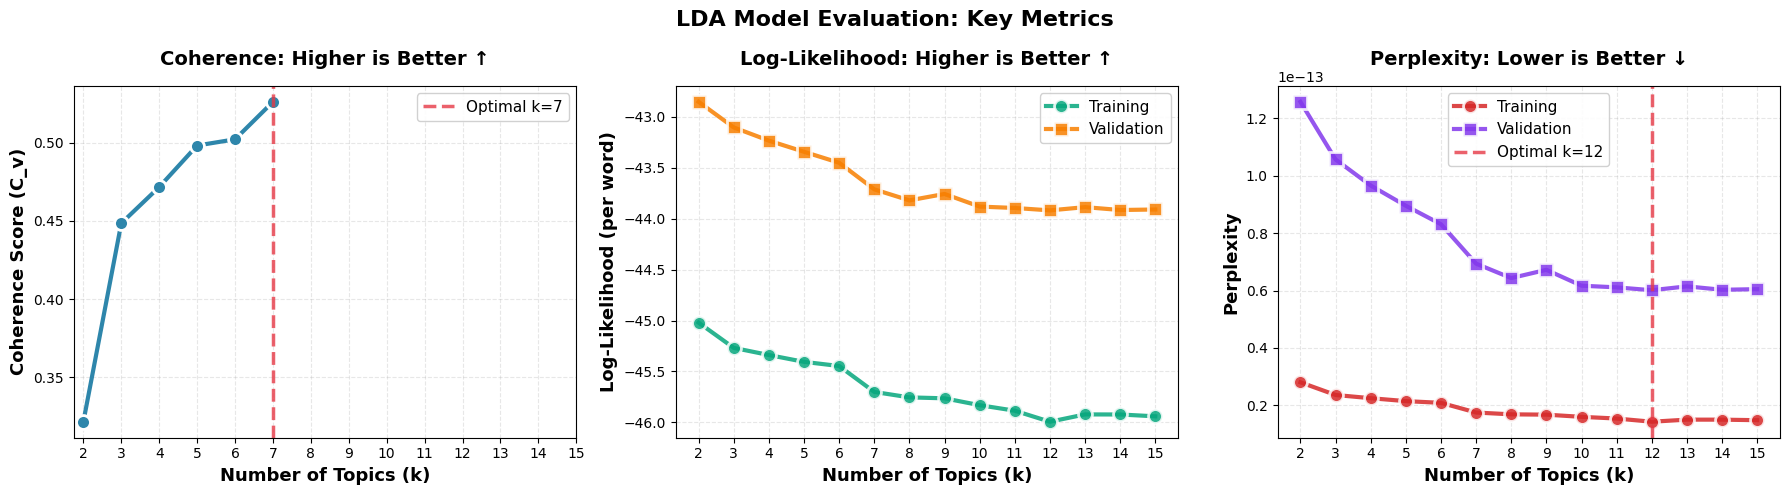


FINAL EVALUATION ON TEST SET

Final Model (k=7) Performance on Test Set:
  ✓ Coherence (C_v):           0.5347
  ✓ Log-Likelihood (per word): -45.1876
  ✓ Perplexity:                0.0000

TOP 10 WORDS PER TOPIC (k=7)

Topic #1:
  service, business, include, order, technology, mobile, make, customer, provide, base

Topic #2:
  say, market, contract, solution, expect, nokia, investment, today, percent, project

Topic #3:
  share, mln, year, total, euro, oyj, per, value, stock, capital

Topic #4:
  eur, million, profit, net, quarter, period, operating, increase, first, loss

Topic #5:
  finnish, finland, group, helsinki, corporation, agreement, facility, construction, pct, sell

Topic #6:
  new, also, product, plant, use, production, well, would, development, one

Topic #7:
  company, sale, operation, system, report, accord, result, unit, financial, price

DIAGNOSTIC ANALYSIS

📈 Expected Behavior:
  TRAINING SET:
    • Log-Likelihood should INCREASE (less negative)
    • Perplexity sho

In [ ]:
import nltk
import numpy as np
import pandas as pd
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- 1. LOAD DATA ---

df.dropna(subset=["cleaned_text"], inplace=True)

# --- 2. SPLIT DATA ---
train_docs, temp_docs = train_test_split(df["cleaned_text"], test_size=0.3, random_state=42)
val_docs, test_docs = train_test_split(temp_docs, test_size=0.5, random_state=42)

print(f"Dataset Split:")
print(f"  Training: {len(train_docs)} documents")
print(f"  Validation: {len(val_docs)} documents")
print(f"  Test: {len(test_docs)} documents\n")

# --- 3. TOKENIZE ---
train_texts = [nltk.word_tokenize(doc.lower()) for doc in train_docs]
val_texts = [nltk.word_tokenize(doc.lower()) for doc in val_docs]
test_texts = [nltk.word_tokenize(doc.lower()) for doc in test_docs]

# --- 4. CREATE DICTIONARY & CORPUS ---
train_dictionary = Dictionary(train_texts)
print(f"Dictionary before filtering: {len(train_dictionary)} unique tokens")

# More conservative filtering for small corpus
train_dictionary.filter_extremes(no_below=5, no_above=0.7, keep_n=None)
print(f"Dictionary after filtering: {len(train_dictionary)} unique tokens\n")

# Create corpora
train_corpus = [train_dictionary.doc2bow(text) for text in train_texts]
val_corpus = [train_dictionary.doc2bow(text) for text in val_texts]
test_corpus = [train_dictionary.doc2bow(text) for text in test_texts]

# Calculate word counts
def get_corpus_word_count(corpus):
    return sum(count for doc in corpus for _, count in doc)

train_word_count = get_corpus_word_count(train_corpus)
val_word_count = get_corpus_word_count(val_corpus)

print(f"Training corpus: {len(train_corpus)} docs, {train_word_count} words")
print(f"Validation corpus: {len(val_corpus)} docs, {val_word_count} words\n")

# --- 5. HYPERPARAMETER TUNING WITH PROPER SETTINGS ---
min_topics = 2
max_topics = 15

results = []
models = {}

print("=" * 90)
print("STARTING HYPERPARAMETER TUNING WITH OPTIMIZED SETTINGS")
print("=" * 90)

for k in range(min_topics, max_topics + 1):
    print(f"\n{'='*90}")
    print(f"Training LDA with {k} topics...")
    print(f"{'='*90}")

    # CRITICAL: Use optimized hyperparameters based on LDA theory
    # Alpha: Document-topic density (lower = fewer topics per doc)
    # Eta (Beta): Topic-word density (lower = fewer words per topic)

    # Calculate optimized priors
    alpha_prior = 50.0 / k  # Asymmetric prior scaled by number of topics
    eta_prior = 0.01        # Sparse topics (fewer words per topic)

    # Train with STANDARD LdaModel (more stable than Multicore)
    lda_model = LdaModel(
        corpus=train_corpus,
        id2word=train_dictionary,
        num_topics=k,
        random_state=42,
        chunksize=100,
        passes=50,              # More passes for convergence
        iterations=200,         # More iterations per document
        alpha=alpha_prior,      # Optimized alpha
        eta=eta_prior,          # Sparse topics
        update_every=1,         # Update model after each chunk
        eval_every=10,          # Log perplexity every 10 chunks
        per_word_topics=False,
        minimum_probability=0.01,
        callbacks=None
    )

    models[k] = lda_model

    # ============================================================
    # EVALUATE ON TRAINING SET (should show improvement)
    # ============================================================
    train_perplexity_raw = lda_model.log_perplexity(train_corpus)
    train_perplexity = np.exp2(train_perplexity_raw)

    # ============================================================
    # EVALUATE ON VALIDATION SET
    # ============================================================
    val_perplexity_raw = lda_model.log_perplexity(val_corpus)
    val_perplexity = np.exp2(val_perplexity_raw)

    # Calculate proper log-likelihood
    # The bound() gives ELBO which approximates log p(w|model)
    train_ll_total = lda_model.bound(train_corpus)
    val_ll_total = lda_model.bound(val_corpus)

    # Normalize by word count for fair comparison
    train_ll_per_word = train_ll_total / train_word_count
    val_ll_per_word = val_ll_total / val_word_count

    # Calculate coherence
    try:
        coherence_model = CoherenceModel(
            model=lda_model,
            texts=val_texts,
            dictionary=train_dictionary,
            coherence='c_v',
            processes=1
        )
        coherence_cv = coherence_model.get_coherence()
    except Exception as e:
        coherence_cv = np.nan
        print(f"  ⚠️  Coherence failed: {e}")

    # Store results
    results.append({
        'num_topics': k,
        'coherence_cv': coherence_cv,
        'train_ll_per_word': train_ll_per_word,
        'val_ll_per_word': val_ll_per_word,
        'train_perplexity': train_perplexity,
        'val_perplexity': val_perplexity
    })

    print(f"\n📊 TRAINING SET Metrics (k={k}):")
    print(f"  ✓ Log-Likelihood (per word): {train_ll_per_word:.4f}")
    print(f"  ✓ Perplexity:                {train_perplexity:.4f}")

    print(f"\n📊 VALIDATION SET Metrics (k={k}):")
    print(f"  ✓ Coherence (C_v):           {coherence_cv:.4f}")
    print(f"  ✓ Log-Likelihood (per word): {val_ll_per_word:.4f}")
    print(f"  ✓ Perplexity:                {val_perplexity:.4f}")

# --- 6. CREATE RESULTS DATAFRAME ---
results_df = pd.DataFrame(results)

print("\n" + "="*90)
print("SUMMARY OF ALL MODELS")
print("="*90)
print(results_df.to_string(index=False))

# --- 7. FIND OPTIMAL K ---
results_clean = results_df.dropna(subset=['coherence_cv'])

if len(results_clean) > 0:
    best_k_coherence = int(results_clean.loc[results_clean['coherence_cv'].idxmax(), 'num_topics'])
    best_k_val_perp = int(results_df.loc[results_df['val_perplexity'].idxmin(), 'num_topics'])

    print("\n" + "="*90)
    print("OPTIMAL NUMBER OF TOPICS")
    print("="*90)
    print(f"Based on Validation Coherence:   k = {best_k_coherence}")
    print(f"Based on Validation Perplexity:  k = {best_k_val_perp}")
else:
    best_k_coherence = 2
    best_k_val_perp = 2

# --- 8. VISUALIZE METRICS (3 plots) ---
x = list(range(min_topics, max_topics + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('LDA Model Evaluation: Key Metrics', fontsize=16, fontweight='bold')

# Plot 1: Coherence Score (Higher is Better)
valid_coh = [(i, c) for i, c in zip(x, results_df['coherence_cv']) if not np.isnan(c)]
if valid_coh:
    x_coh, y_coh = zip(*valid_coh)
    axes[0].plot(x_coh, y_coh, 'o-', color='#2E86AB', linewidth=3, markersize=10,
                 markeredgewidth=2, markeredgecolor='white')
    axes[0].axvline(x=best_k_coherence, color='#E63946', linestyle='--',
                    linewidth=2.5, alpha=0.8, label=f'Optimal k={best_k_coherence}')
axes[0].set_xlabel('Number of Topics (k)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Coherence Score (C_v)', fontsize=13, fontweight='bold')
axes[0].set_title('Coherence: Higher is Better ↑', fontsize=14, fontweight='bold', pad=15)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].legend(fontsize=11, framealpha=0.9)
axes[0].set_xticks(x)

# Plot 2: Log-Likelihood (Higher is Better)
axes[1].plot(x, results_df['train_ll_per_word'], 'o-', color='#06A77D',
             linewidth=3, markersize=10, label='Training', alpha=0.85,
             markeredgewidth=2, markeredgecolor='white')
axes[1].plot(x, results_df['val_ll_per_word'], 's-', color='#F77F00',
             linewidth=3, markersize=10, label='Validation', alpha=0.85,
             markeredgewidth=2, markeredgecolor='white')
axes[1].set_xlabel('Number of Topics (k)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Log-Likelihood (per word)', fontsize=13, fontweight='bold')
axes[1].set_title('Log-Likelihood: Higher is Better ↑', fontsize=14, fontweight='bold', pad=15)
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].legend(fontsize=11, framealpha=0.9)
axes[1].set_xticks(x)

# Plot 3: Perplexity (Lower is Better)
axes[2].plot(x, results_df['train_perplexity'], 'o-', color='#D62828',
             linewidth=3, markersize=10, label='Training', alpha=0.85,
             markeredgewidth=2, markeredgecolor='white')
axes[2].plot(x, results_df['val_perplexity'], 's-', color='#8338EC',
             linewidth=3, markersize=10, label='Validation', alpha=0.85,
             markeredgewidth=2, markeredgecolor='white')
axes[2].axvline(x=best_k_val_perp, color='#E63946', linestyle='--',
                linewidth=2.5, alpha=0.8, label=f'Optimal k={best_k_val_perp}')
axes[2].set_xlabel('Number of Topics (k)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Perplexity', fontsize=13, fontweight='bold')
axes[2].set_title('Perplexity: Lower is Better ↓', fontsize=14, fontweight='bold', pad=15)
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].legend(fontsize=11, framealpha=0.9)
axes[2].set_xticks(x)

plt.tight_layout()
plt.show()

# --- 9. EVALUATE BEST MODEL ON TEST SET ---
print("\n" + "="*90)
print("FINAL EVALUATION ON TEST SET")
print("="*90)

final_k = best_k_coherence
best_model = models[final_k]

test_word_count = get_corpus_word_count(test_corpus)
test_ll_total = best_model.bound(test_corpus)
test_ll_per_word = test_ll_total / test_word_count
test_perplexity_raw = best_model.log_perplexity(test_corpus)
test_perplexity = np.exp2(test_perplexity_raw)

try:
    test_coherence = CoherenceModel(
        model=best_model,
        texts=test_texts,
        dictionary=train_dictionary,
        coherence='c_v',
        processes=1
    ).get_coherence()
except:
    test_coherence = np.nan

print(f"\nFinal Model (k={final_k}) Performance on Test Set:")
print(f"  ✓ Coherence (C_v):           {test_coherence:.4f}")
print(f"  ✓ Log-Likelihood (per word): {test_ll_per_word:.4f}")
print(f"  ✓ Perplexity:                {test_perplexity:.4f}")

# --- 10. DISPLAY TOP WORDS ---
print("\n" + "="*90)
print(f"TOP 10 WORDS PER TOPIC (k={final_k})")
print("="*90)

for idx, topic in best_model.print_topics(num_topics=final_k, num_words=10):
    print(f"\nTopic #{idx + 1}:")
    words = [w.split('*')[1].replace('"', '').strip() for w in topic.split('+')]
    print(f"  {', '.join(words)}")

# --- 11. DIAGNOSTIC ANALYSIS ---
print("\n" + "="*90)
print("DIAGNOSTIC ANALYSIS")
print("="*90)

print("\n📈 Expected Behavior:")
print("  TRAINING SET:")
print("    • Log-Likelihood should INCREASE (less negative)")
print("    • Perplexity should DECREASE")
print("  VALIDATION SET:")
print("    • Log-Likelihood may peak then decrease (overfitting)")
print("    • Perplexity may bottom out then increase (overfitting)")
print("    • Coherence should peak at optimal interpretability")

# Check if training is improving
train_ll_trend = results_df['train_ll_per_word'].iloc[-1] - results_df['train_ll_per_word'].iloc[0]
train_perp_trend = results_df['train_perplexity'].iloc[-1] - results_df['train_perplexity'].iloc[0]

print(f"\n📊 Observed Trends:")
print(f"  Training LL change (k=2 to k={max_topics}):   {train_ll_trend:+.4f}")
print(f"  Training Perp change (k=2 to k={max_topics}): {train_perp_trend:+.4f}")

if train_ll_trend > 0:
    print("  ✅ Training log-likelihood is improving (GOOD)")
else:
    print("  ⚠️  Training log-likelihood is degrading (PROBLEM)")

if train_perp_trend < 0:
    print("  ✅ Training perplexity is decreasing (GOOD)")
else:
    print("  ⚠️  Training perplexity is increasing (PROBLEM)")

print("\n" + "="*90)
print("TUNING COMPLETE!")
print("="*90)

In [ ]:
!pip install pyLDAvis

In [ ]:
# @title
import pandas as pd
import numpy as np
import nltk
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import io

# 70% Train, 30% Temp (which will be split into 15% validation, 15% test)
train_docs, temp_docs = train_test_split(df['cleaned_text'], test_size=0.3, random_state=42)
val_docs, test_docs = train_test_split(temp_docs, test_size=0.5, random_state=42)

print(f"\nNumber of training documents: {len(train_docs)}")
print(f"Number of validation documents: {len(val_docs)}")
print(f"Number of test documents: {len(test_docs)}\n")

# Tokenize the documents for Gensim
train_texts = [doc.split() for doc in train_docs]
val_texts = [doc.split() for doc in val_docs]
test_texts = [doc.split() for doc in test_docs]


# --- 3. CREATE DICTIONARY AND CORPUS ---
# Create a dictionary from the training data only
train_dictionary = Dictionary(train_texts)

# Filter out extreme values (e.g., words appearing in < 5 docs or > 50% of docs)
train_dictionary.filter_extremes(no_below=10, no_above=0.5)
print("Dictionary created and filtered.")
print(f"Dictionary size: {len(train_dictionary)}")

# Create Bag-of-Words (BoW) corpora for all sets using the train_dictionary
train_corpus = [train_dictionary.doc2bow(text) for text in train_texts]
val_corpus = [train_dictionary.doc2bow(text) for text in val_texts]
test_corpus = [train_dictionary.doc2bow(text) for text in test_texts]

# --- 4. FIND OPTIMAL NUMBER OF TOPICS ---
min_topics, max_topics = 2, 25
coherence_scores = []
perplexity_scores = []

for k in range(min_topics, max_topics + 1):
    print(f"Training LDA model with {k} topics...")
    lda_model = LdaModel(
        corpus=train_corpus,
        id2word=train_dictionary,
        num_topics=k,
        random_state=100,
        chunksize=100,
        passes=10,
        alpha=0.1,
        eta=0.1,
        per_word_topics=True
    )

    # Calculate Coherence Score (C_v) on the training set
    coherence_model_lda = CoherenceModel(
        model=lda_model,
        texts=train_texts,  # Use tokenized train texts
        dictionary=train_dictionary,
        coherence='c_v'
    )
    coherence_score = coherence_model_lda.get_coherence()
    coherence_scores.append(coherence_score)

    # Calculate Perplexity on the validation set
    log_perplexity = lda_model.log_perplexity(val_corpus)
    perplexity = np.exp2(-log_perplexity)
    perplexity_scores.append(perplexity)

    print(f"  -> Coherence (C_v): {coherence_score:.4f}")
    # print(f"  -> Perplexity: {perplexity:.4f}\n")

# --- 5. PLOT THE RESULTS ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Coherence Score
color = 'tab:blue'
ax1.set_xlabel('Number of Topics (K)')
ax1.set_ylabel('Coherence Score (C_v)', color=color)
ax1.plot(range(min_topics, max_topics + 1), coherence_scores, marker='o', color=color, label='Coherence Score')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

# Create a second y-axis for Perplexity
# ax2 = ax1.twinx()
# color = 'tab:red'
# ax2.set_ylabel('Perplexity', color=color)
# ax2.plot(range(min_topics, max_topics + 1), perplexity_scores, marker='o', color=color, label='Perplexity')
# ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Model Coherence by Number of Topics')
plt.xticks(range(min_topics, max_topics + 1))
plt.grid(True)
plt.show()

In [ ]:

# Vectorize cleaned text
vectorizer = CountVectorizer()

df.dropna(subset=['cleaned_text'], inplace=True)
dtm = vectorizer.fit_transform(df['cleaned_text'])

# Train LDA
lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda.fit(dtm)
feature_names = vectorizer.get_feature_names_out()
# Number of top words per topic
n_top_words = 10

# Extract top words for each topic
topics = []
for topic_idx, topic in enumerate(lda.components_):
    top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
    top_features = [feature_names[i] for i in top_features_ind]
    top_weights = topic[top_features_ind]
    topic_description = " ".join(top_features)
    topics.append((topic_idx, topic_description))

# Save topics to CSV
topics_df = pd.DataFrame(topics, columns=['Topic', 'Top_Words'])
topics_df.to_csv('lda_topics.csv', index=False)

print("Topics saved to lda_topics.csv")

NameError: name 'CountVectorizer' is not defined

In [ ]:
df2 = pd.read_csv('lda_topics.csv')
print(df2)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
#from sklearn.decomposition import LatentDirichletAllocation
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

# Preprocess sentences (simple example)
stop_words = stopwords.words('english')
def preprocess_text(text):
    tokens = text.lower().split()
    return ' '.join([word for word in tokens if word not in stop_words])

df['cleaned'] = df['sentence'].apply(preprocess_text)

# Vectorize
vectorizer = CountVectorizer()
dtm = vectorizer.fit_transform(df['cleaned'])

# Train LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)


In [ ]:
# @title
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    tokens = nltk.word_tokenize(text)  # tokenize
    tokens = [token for token in tokens if token.isalpha()]  # remove numbers and punctuation tokens
    tokens = [token for token in tokens if token not in stop_words]  # remove stopwords
    tokens = [lemmatizer.lemmatize(token) for token in tokens]  # lemmatize
    tokens = [token for token in tokens if len(token) > 2]  # remove short tokens
    return ' '.join(tokens)

# Apply preprocessing
cleaned_lines = [preprocess_text(line) for line in text_data]

# Save and reload as you did before


In [ ]:
# @title
from google.colab import files
import re
import csv
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab') # Download the missing resource

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

with open(file_name, 'r', encoding='latin-1') as f:
    text_data = f.readlines()

def clean_text(line):
    text = line.lower()  # lowercase
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    tokens = nltk.word_tokenize(text)  # tokenize
    tokens = [token for token in tokens if token.isalpha()]  # remove numbers and punctuation tokens
    tokens = [token for token in tokens if token not in stop_words]  # remove stopwords
    tokens = [lemmatizer.lemmatize(token) for token in tokens]  # lemmatize
    tokens = [token for token in tokens if len(token) > 2]  # remove short tokens
    return ' '.join(tokens)


# Apply cleaning to each line
cleaned_lines = [clean_text(line) for line in text_data]

# Save cleaned lines to a CSV file with a single column
cleaned_csv_file_name = 'cleaned_text_file.csv'
with open(cleaned_csv_file_name, 'w', encoding='utf-8', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['cleaned_text'])  # header
    for line in cleaned_lines:
        writer.writerow([line])

# Download the cleaned CSV file
files.download(cleaned_csv_file_name)

print("Text file preprocessing complete. Cleaned CSV file is ready for download.")